<a href="https://colab.research.google.com/github/YuriFla94/Procesin/blob/main/Tarefa7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Design do filtro: (a) Passa-baixas ---


/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


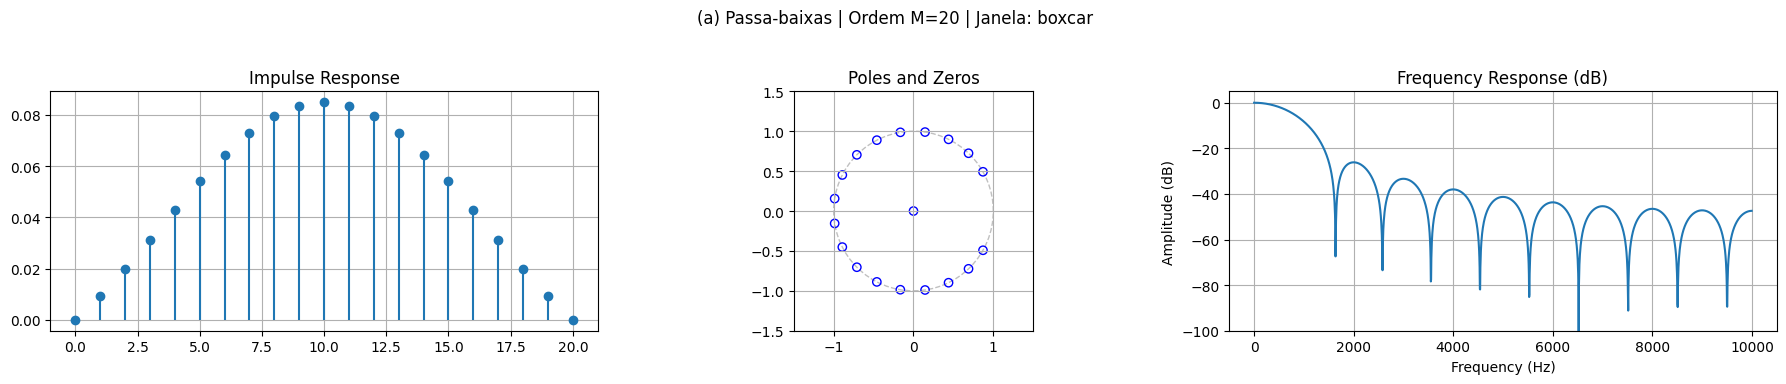

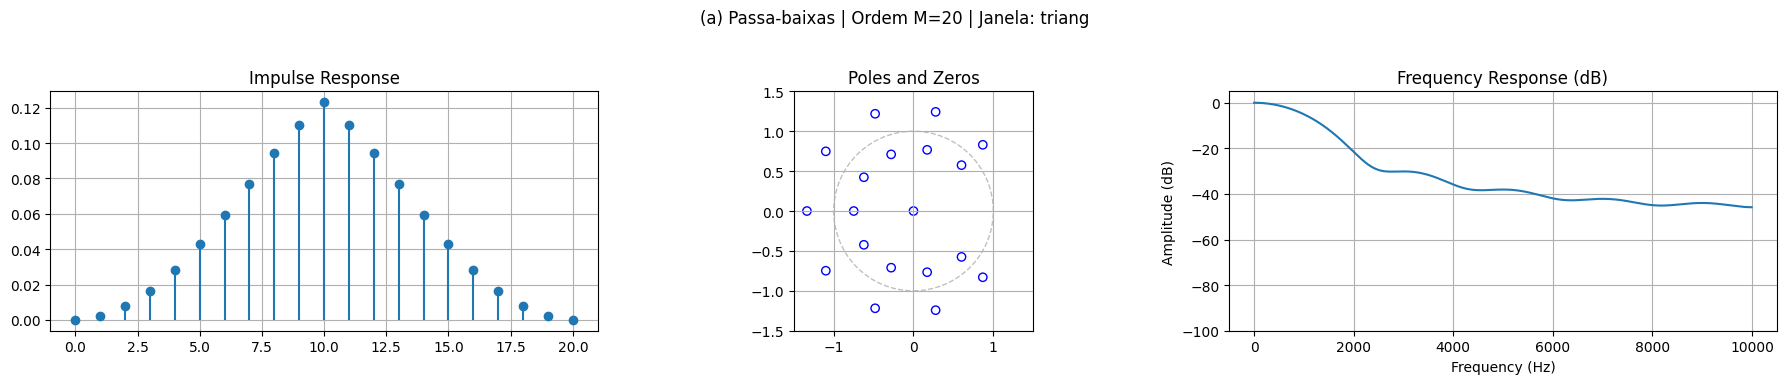

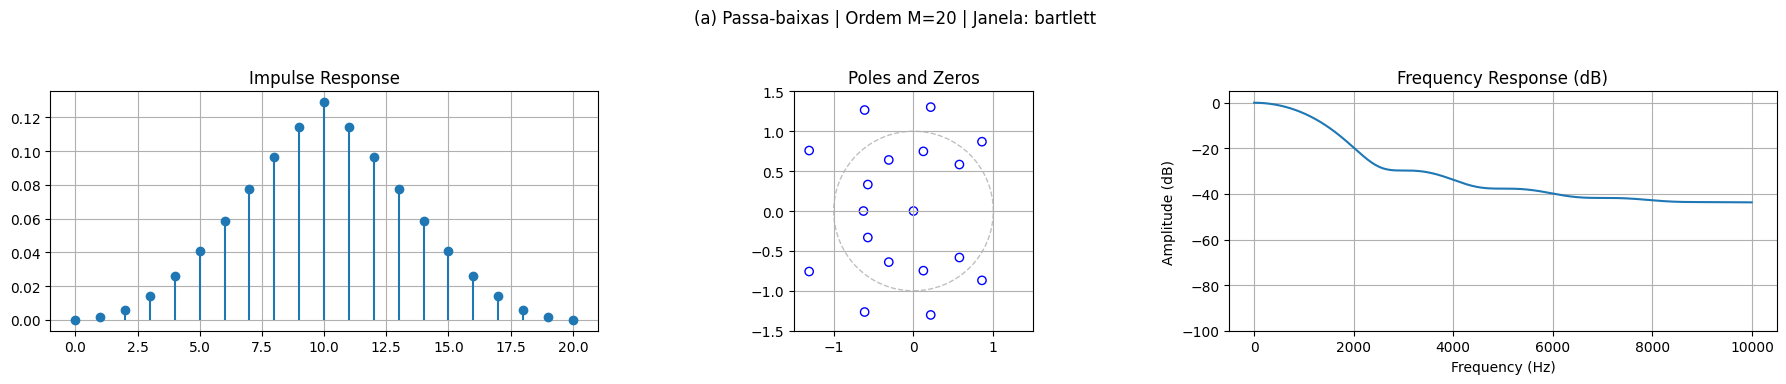

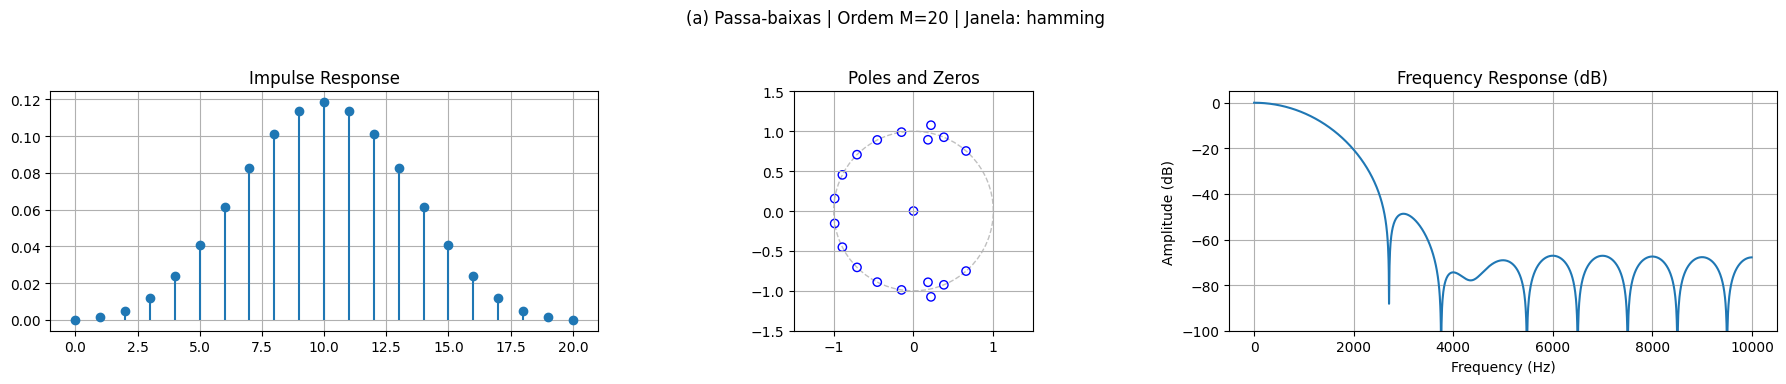

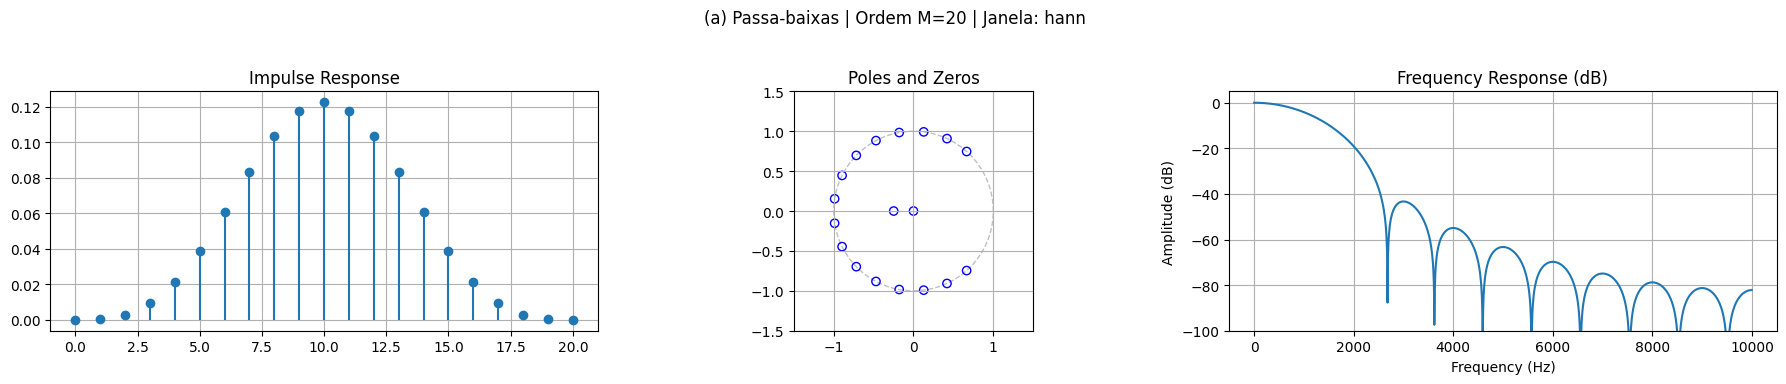

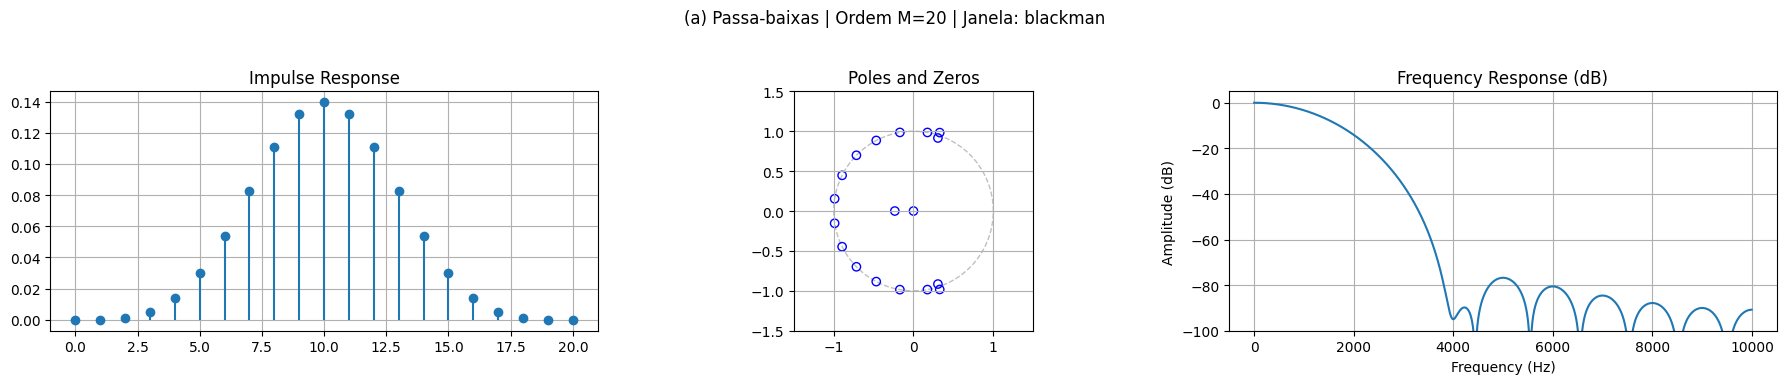

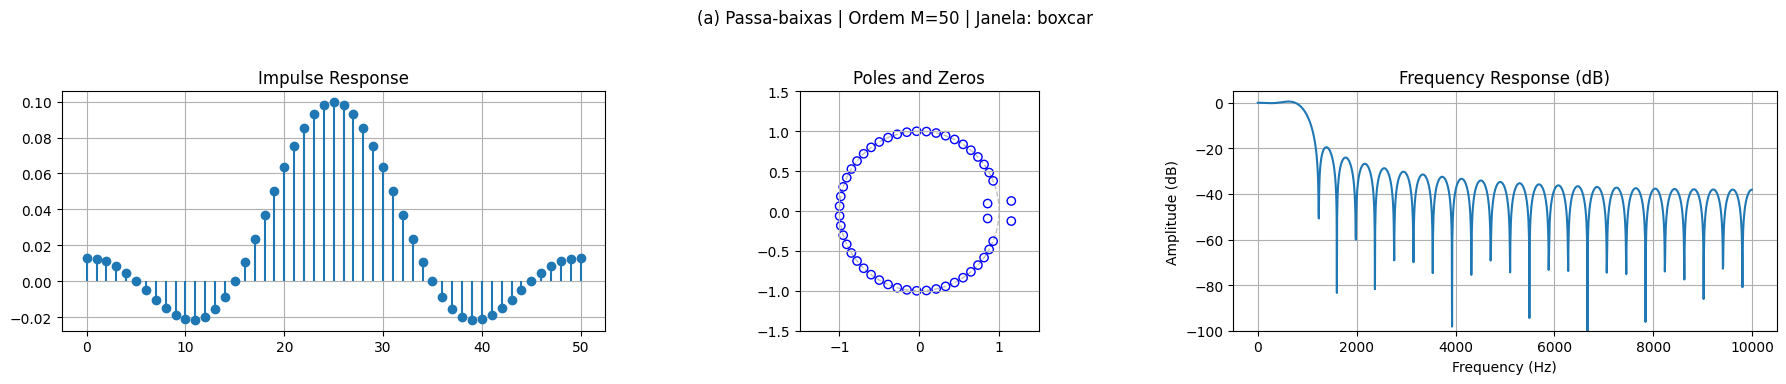

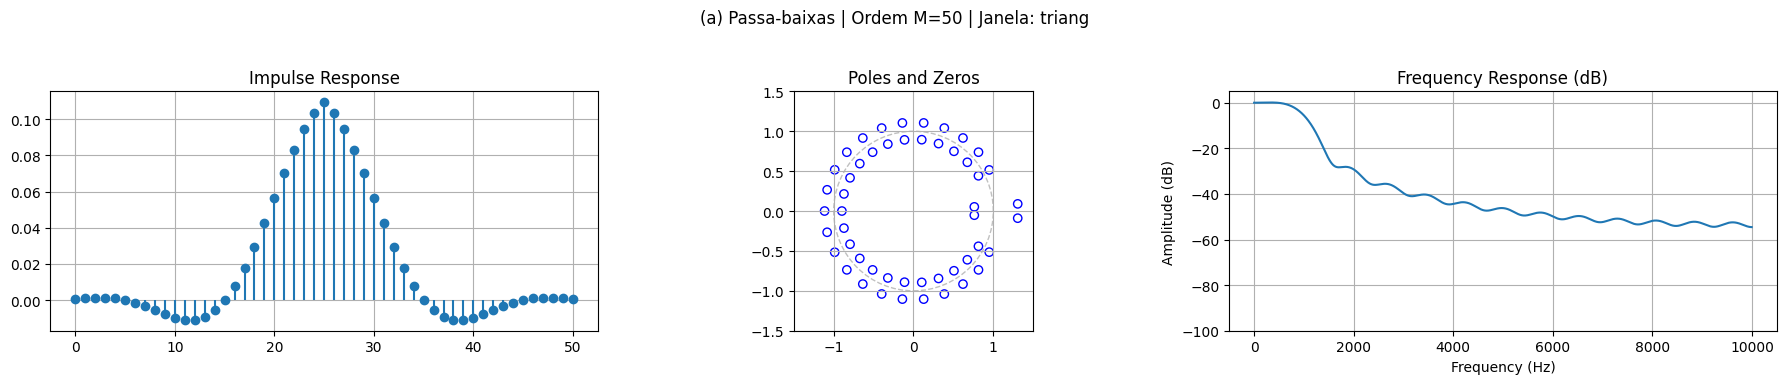

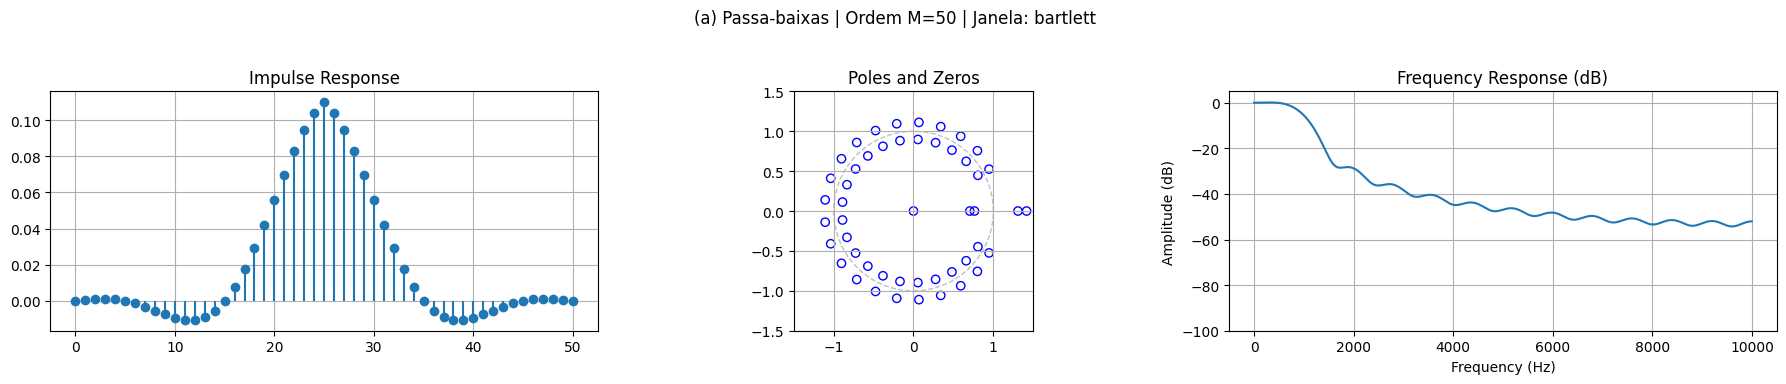

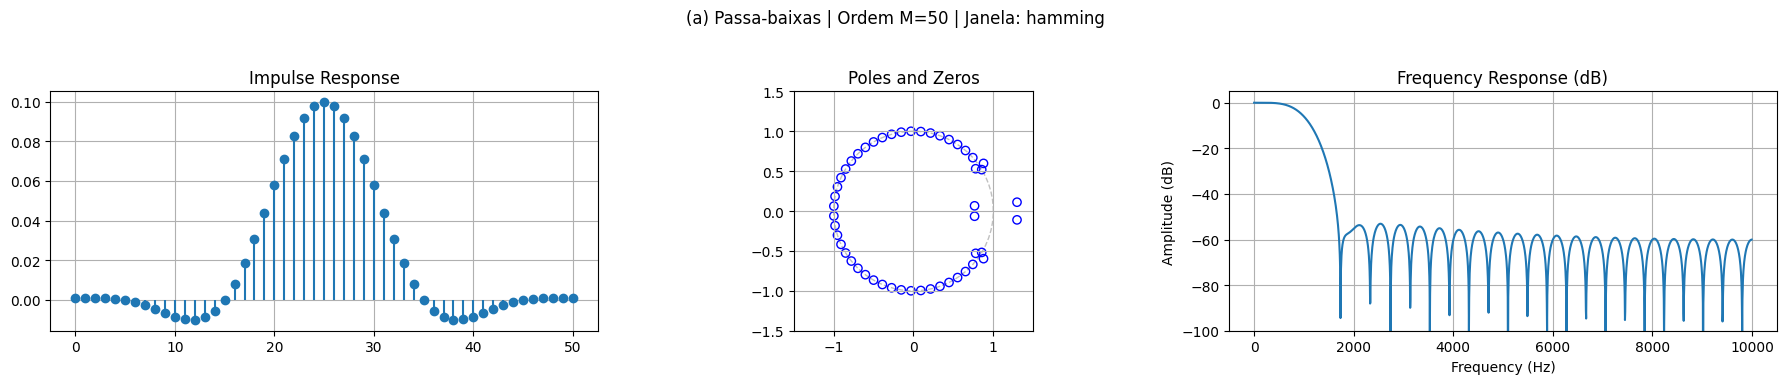

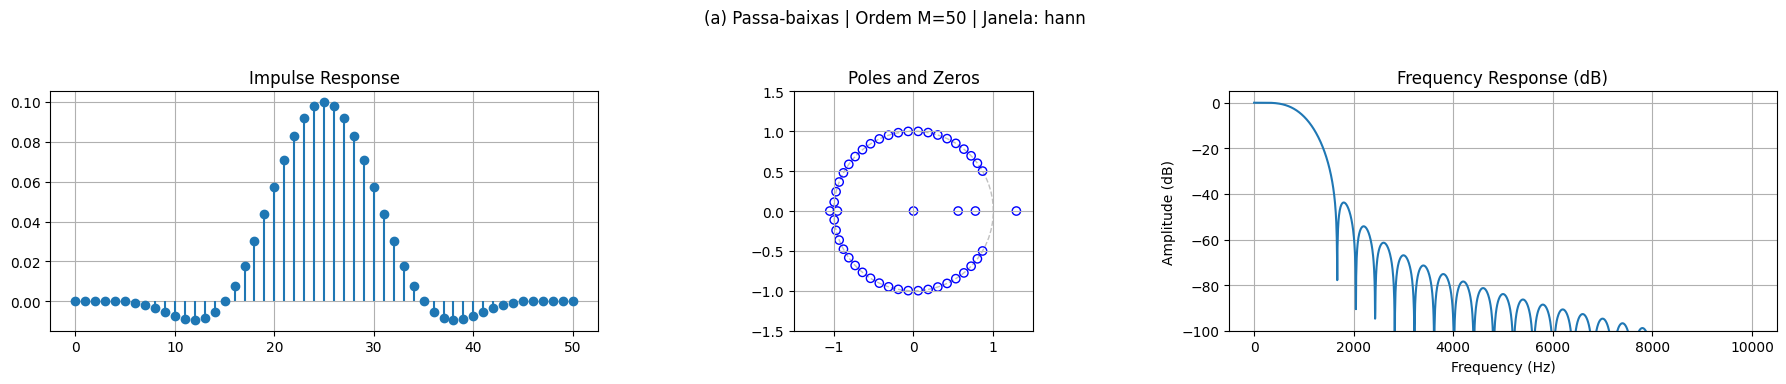

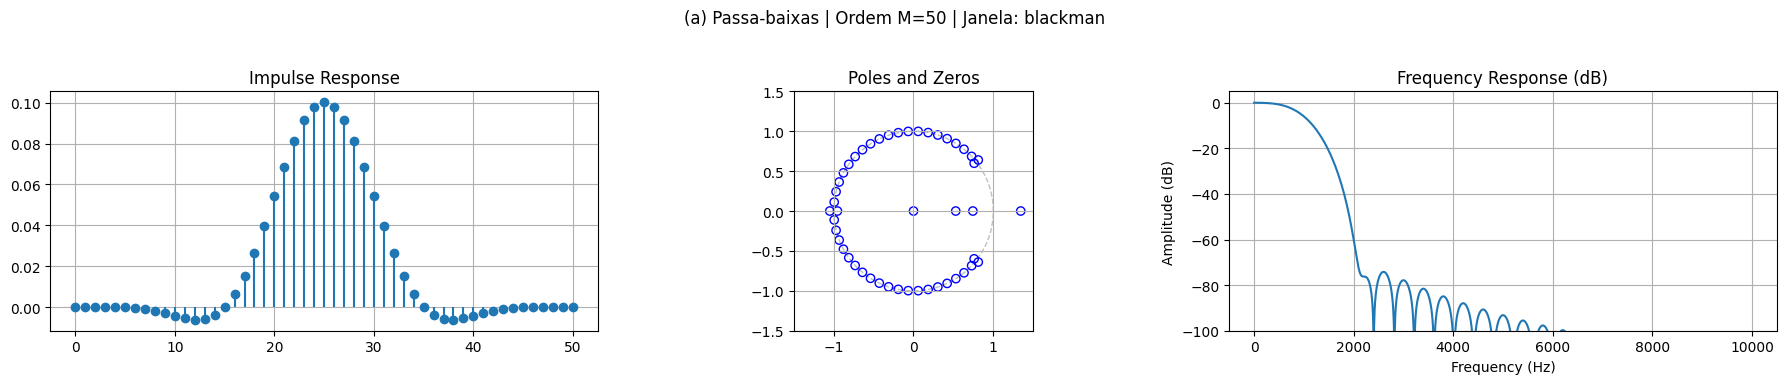

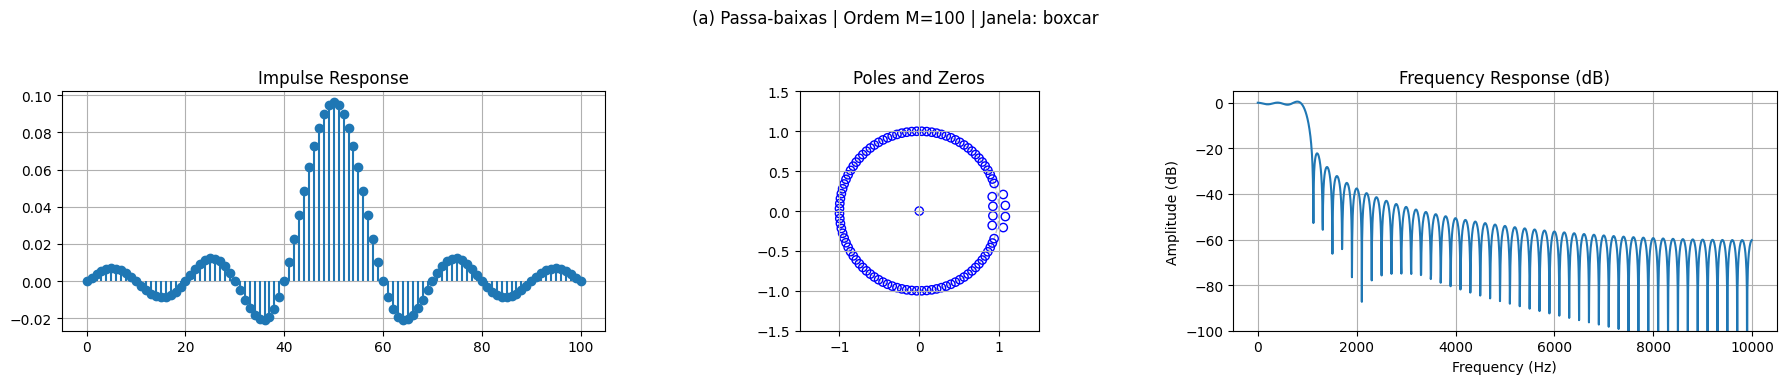

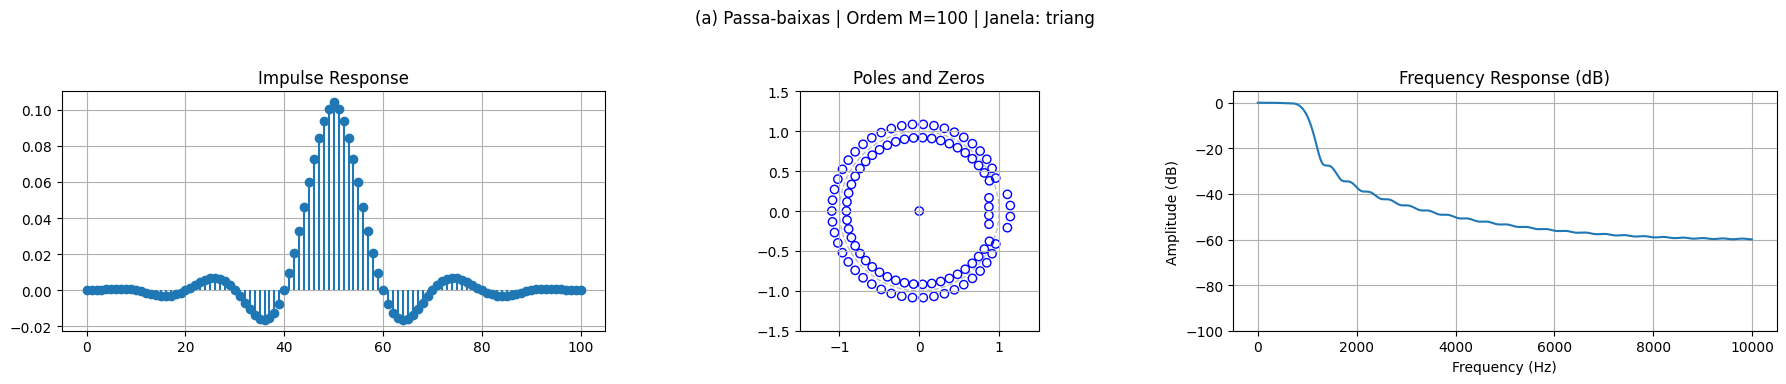

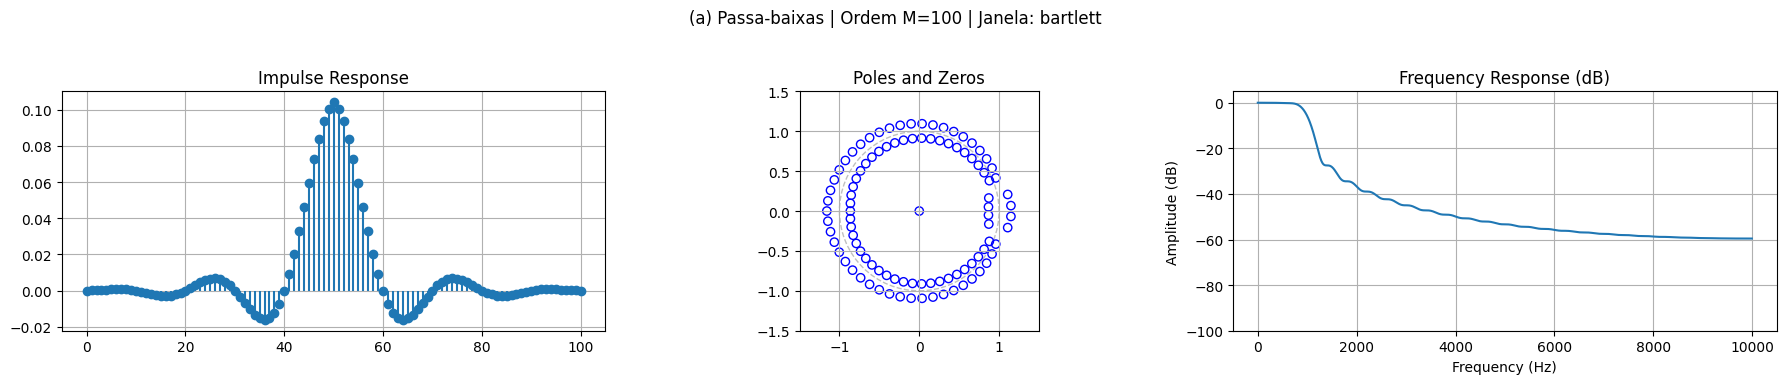

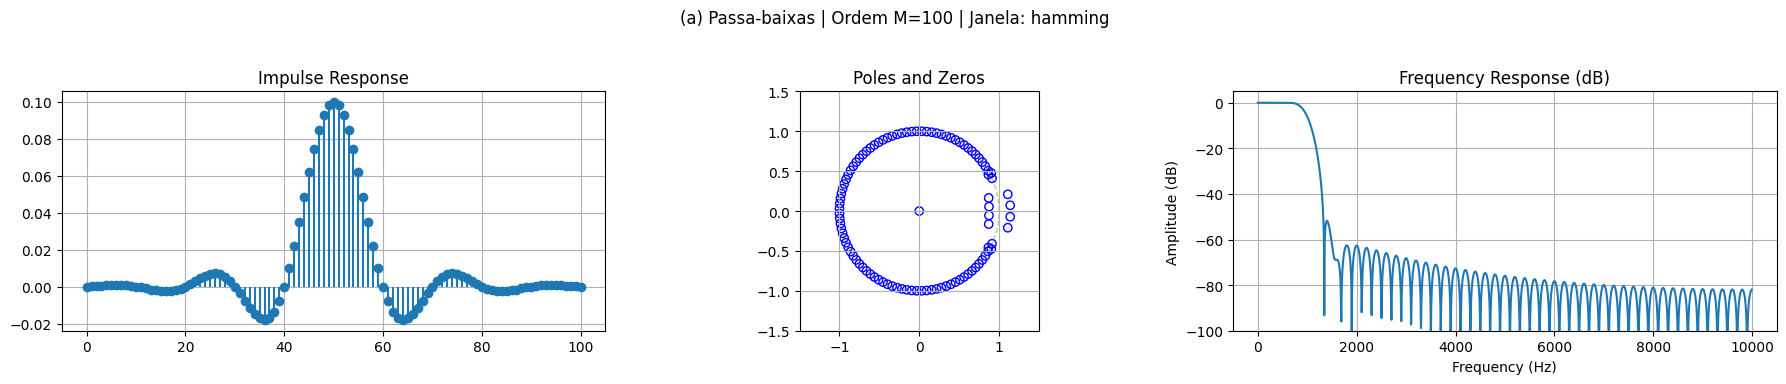

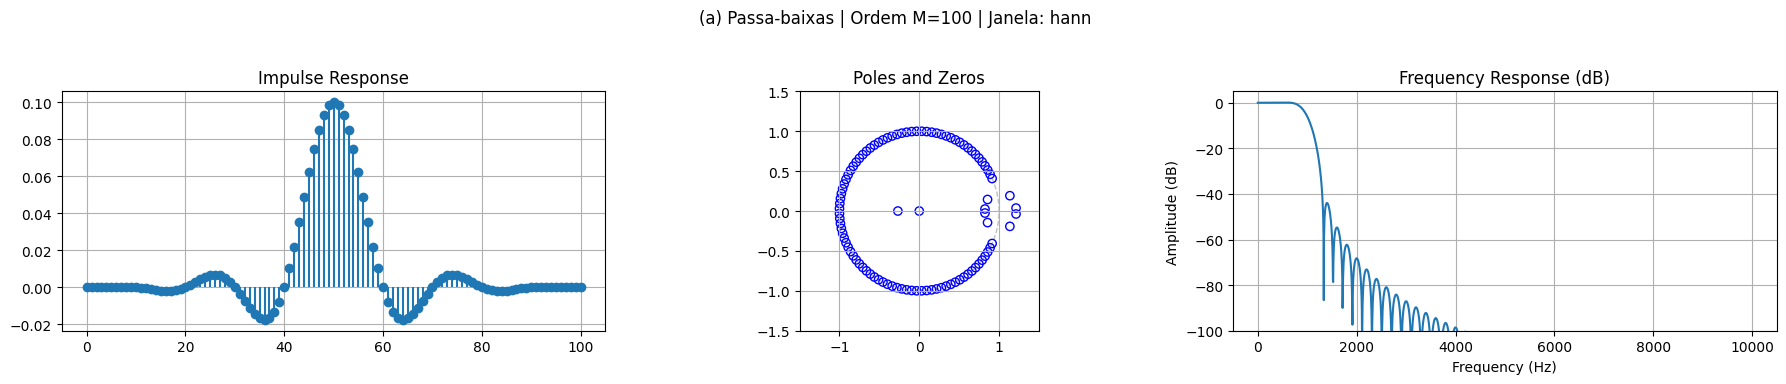

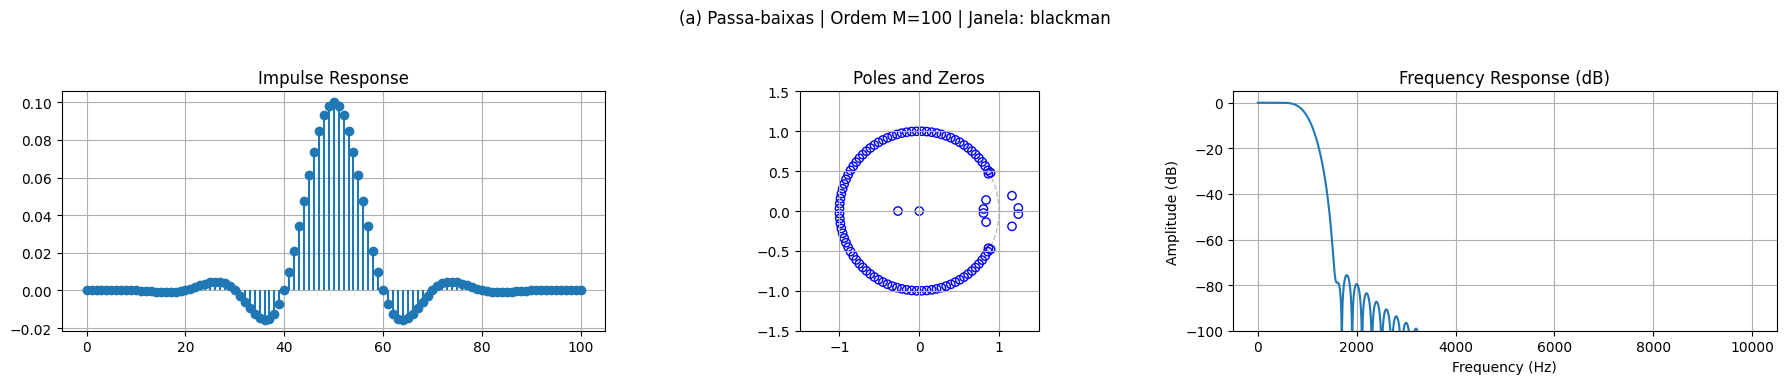


--- Design do filtro: (b) Passa-altas ---


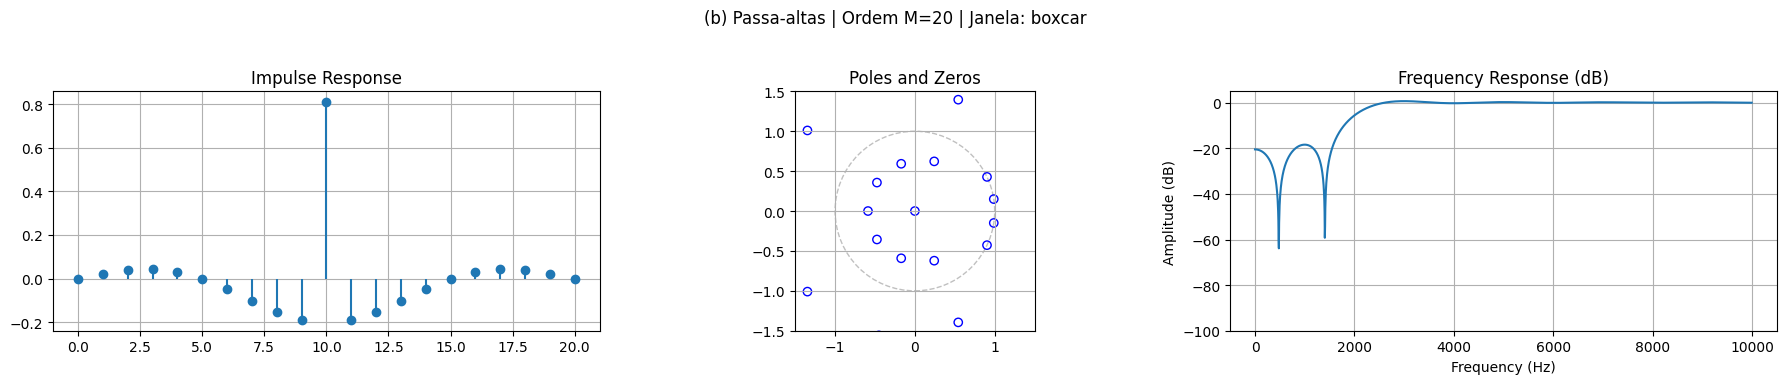

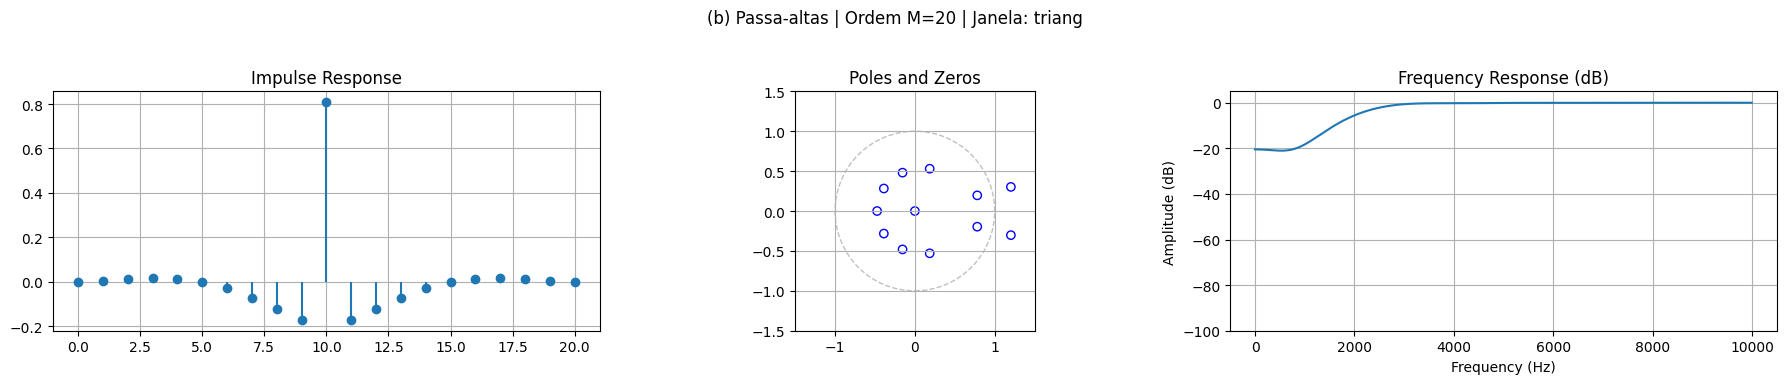

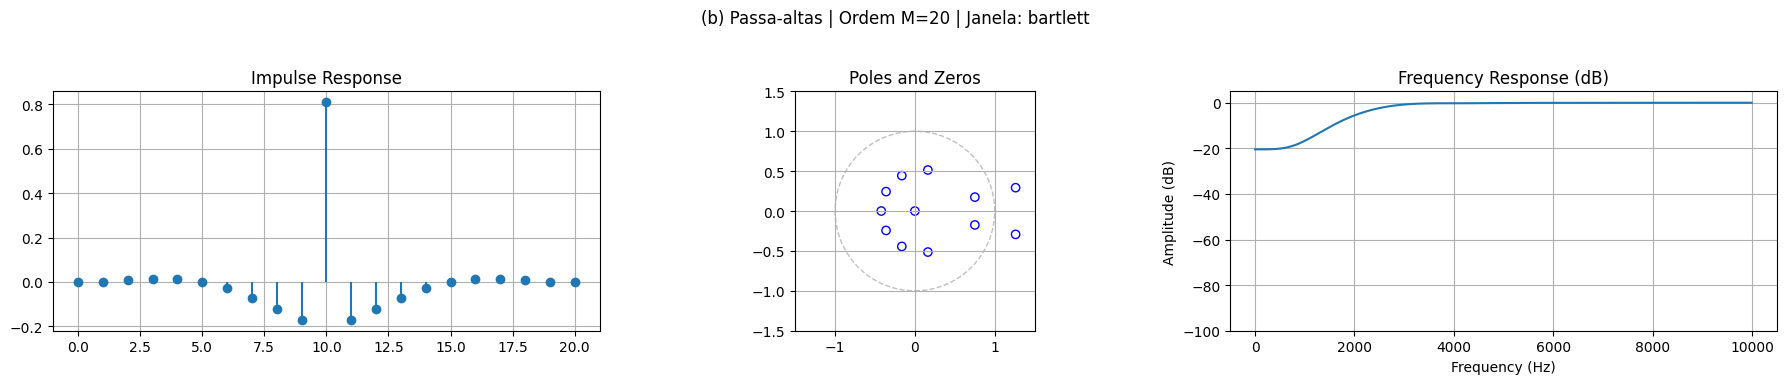

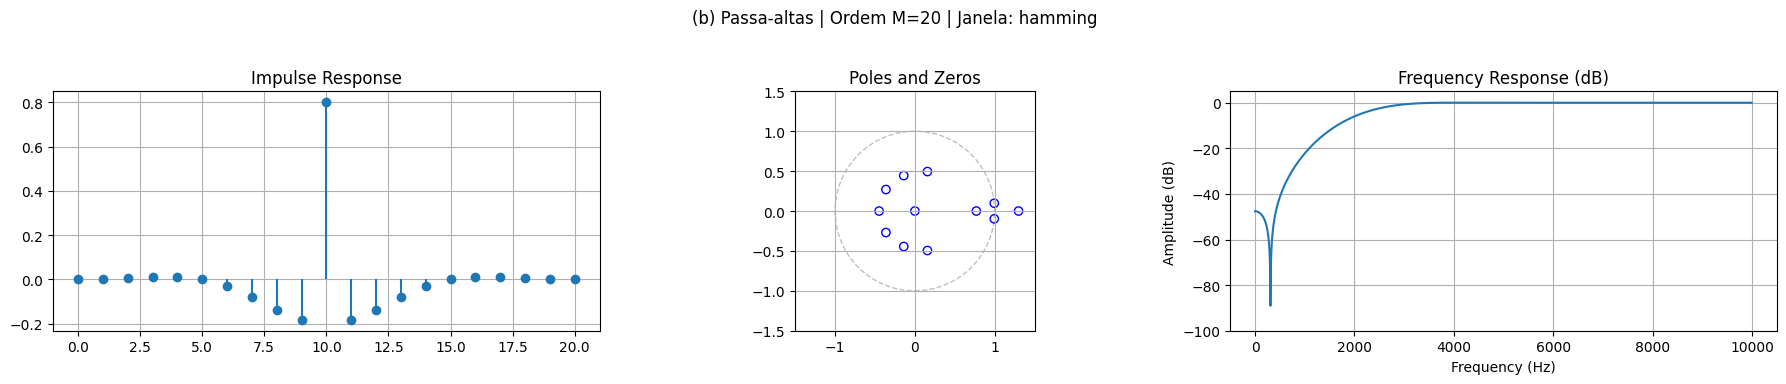

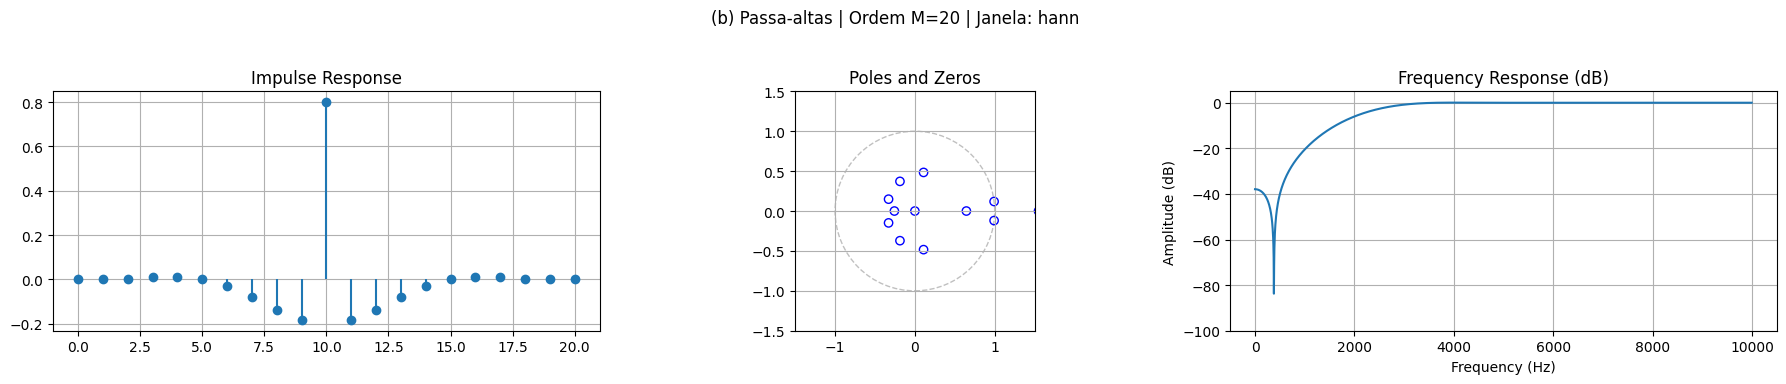

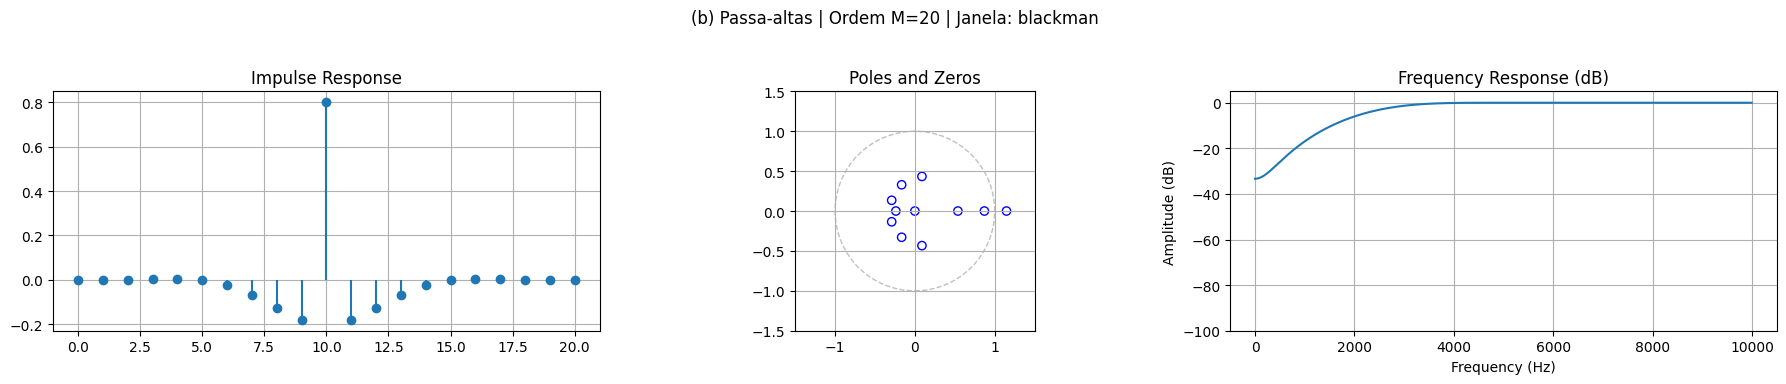

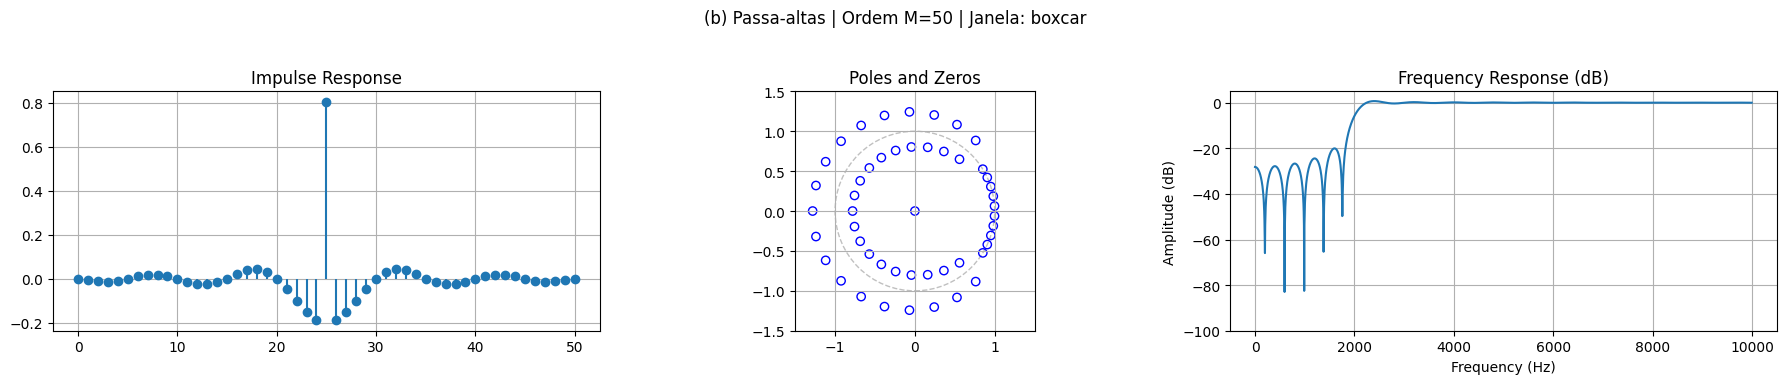

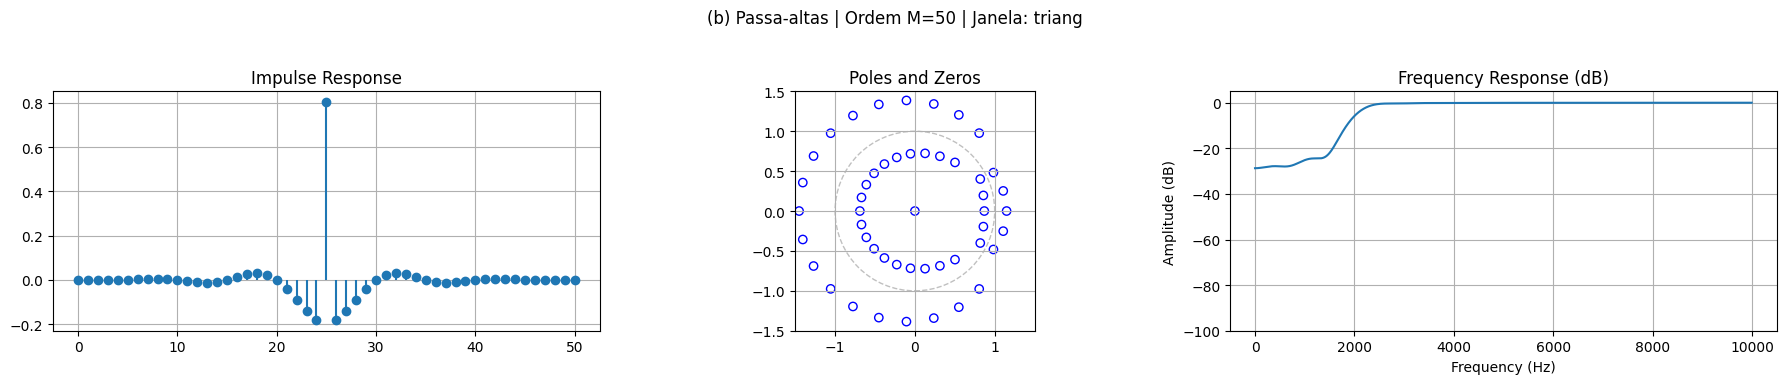

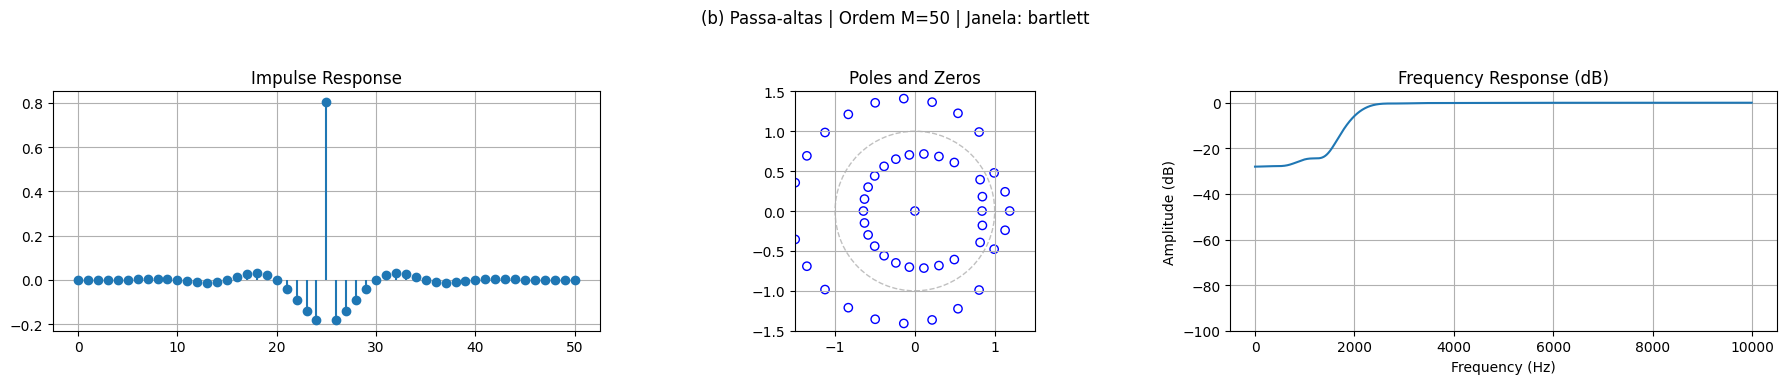

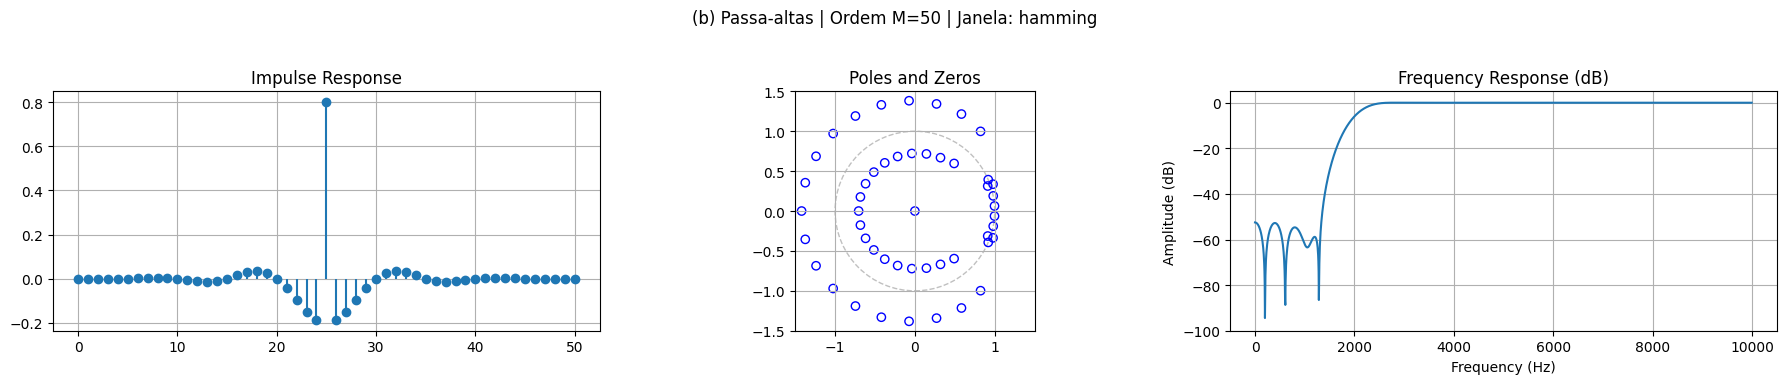

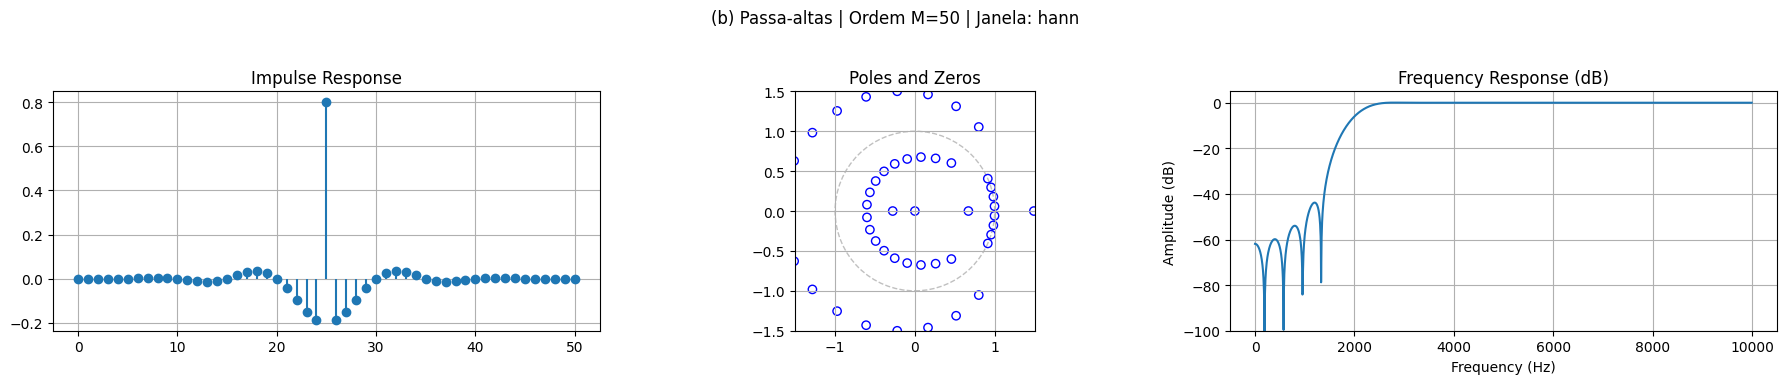

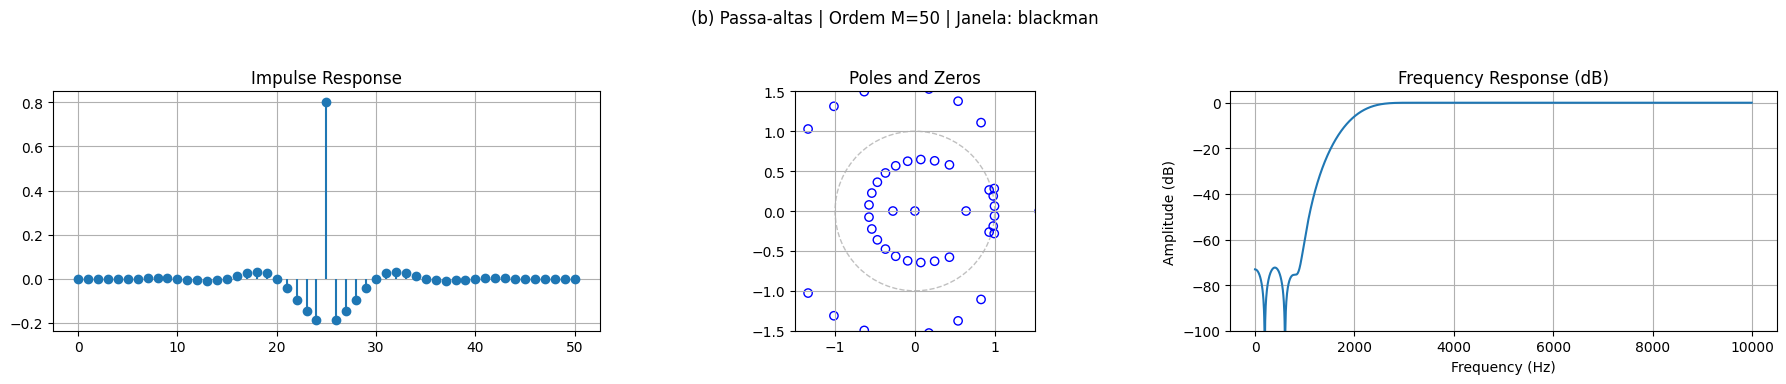

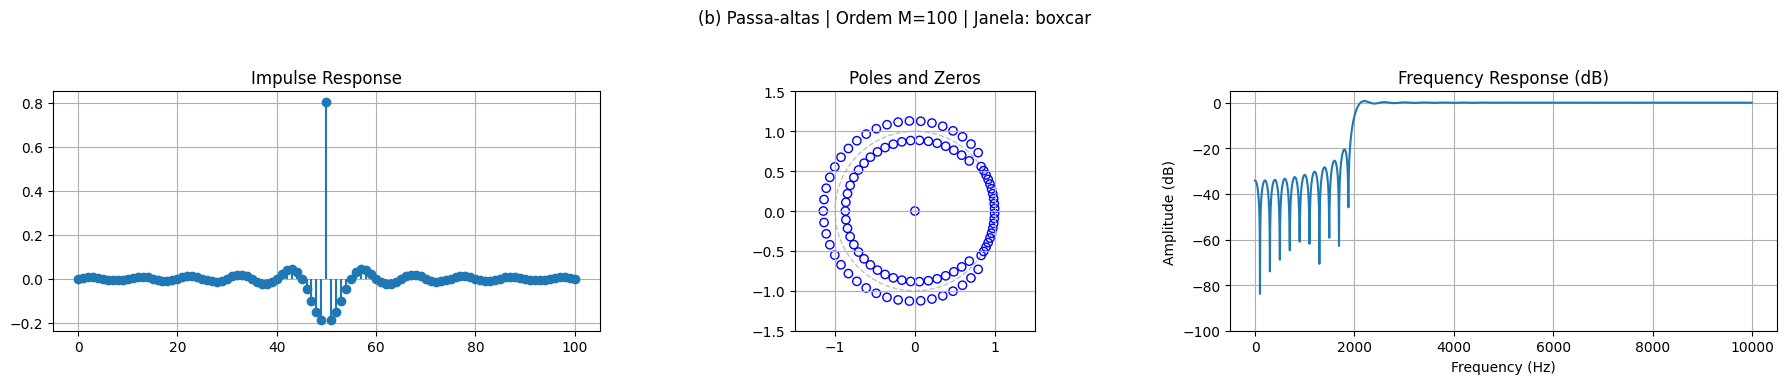

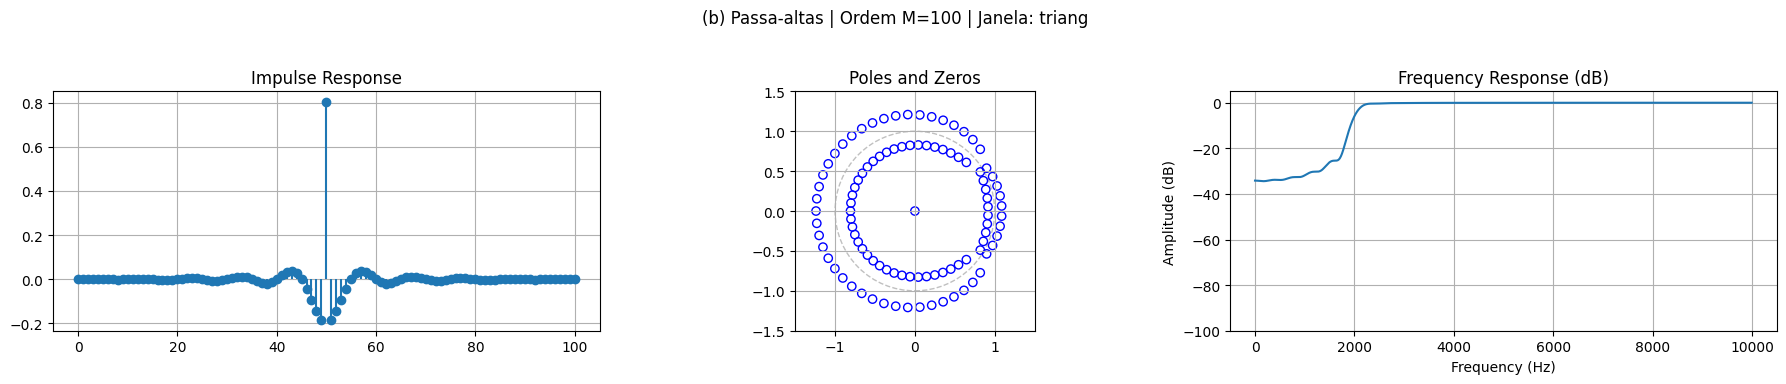

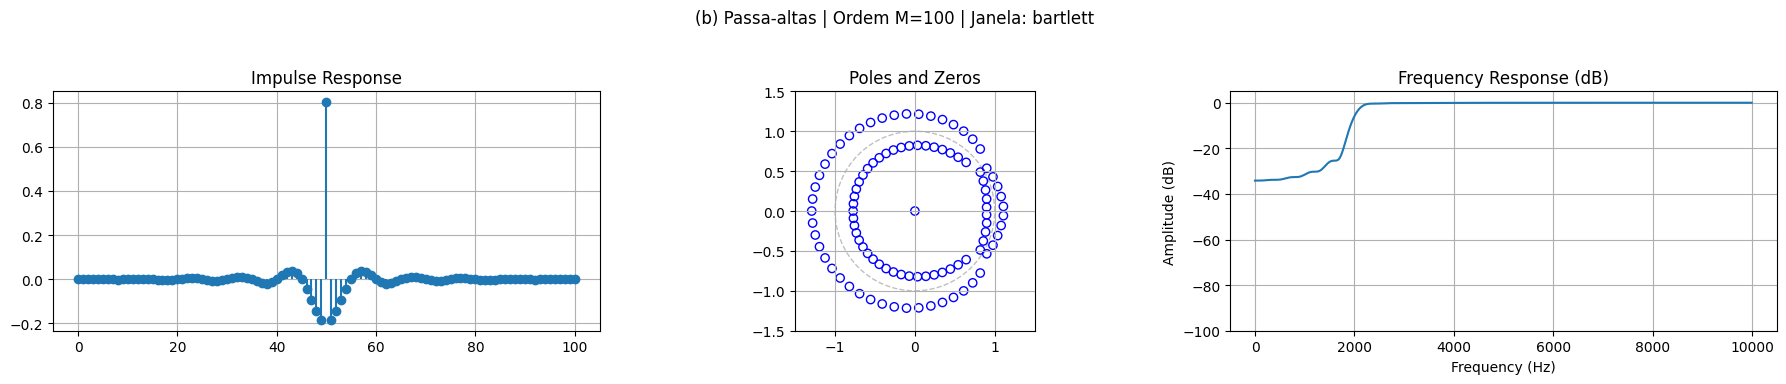

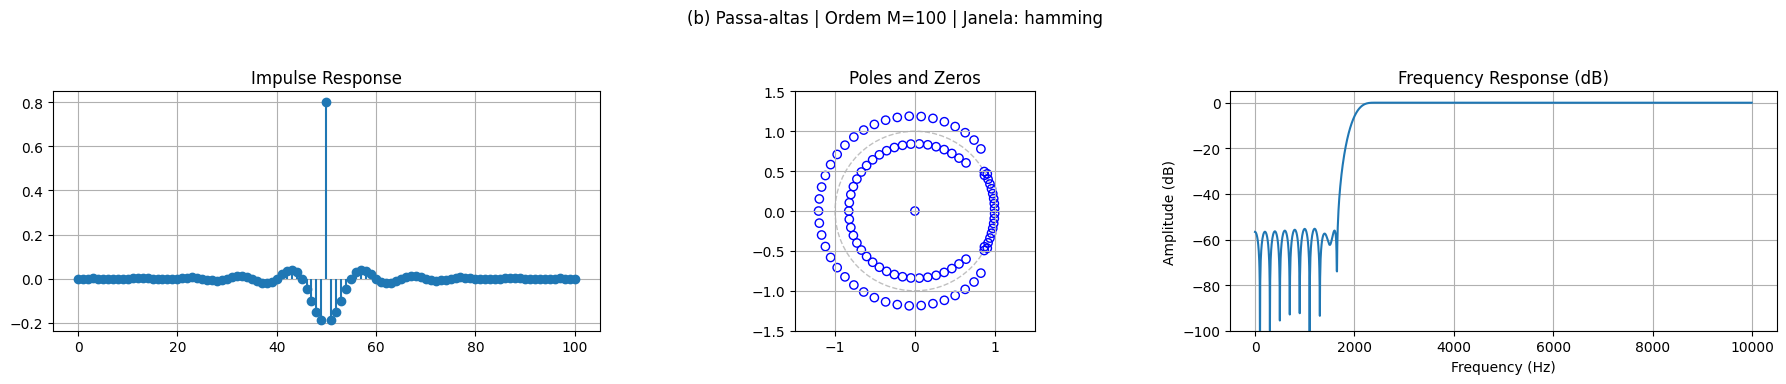

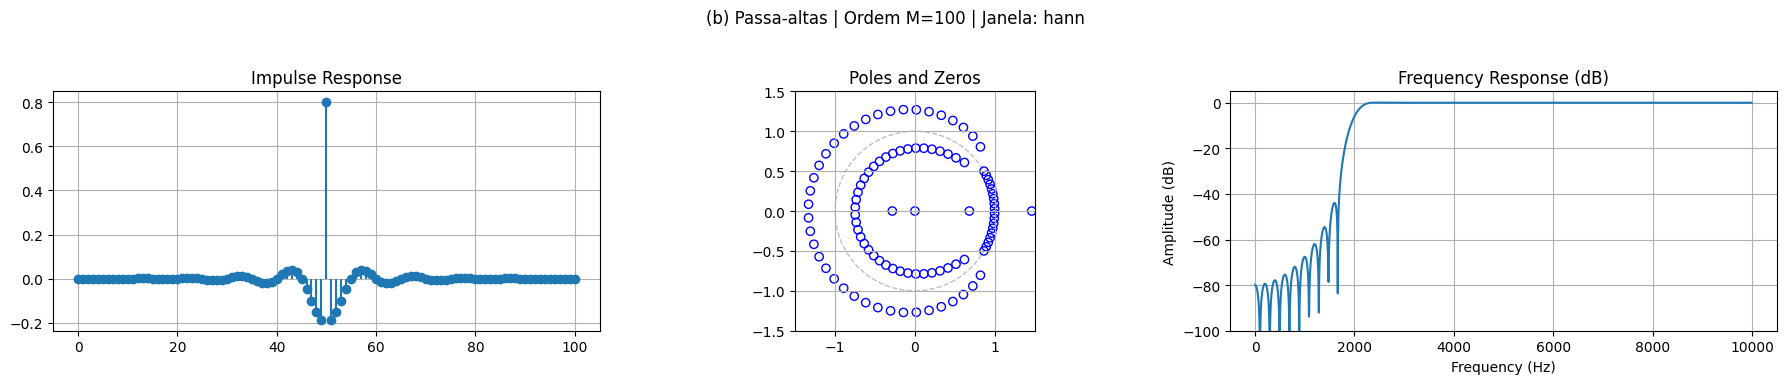

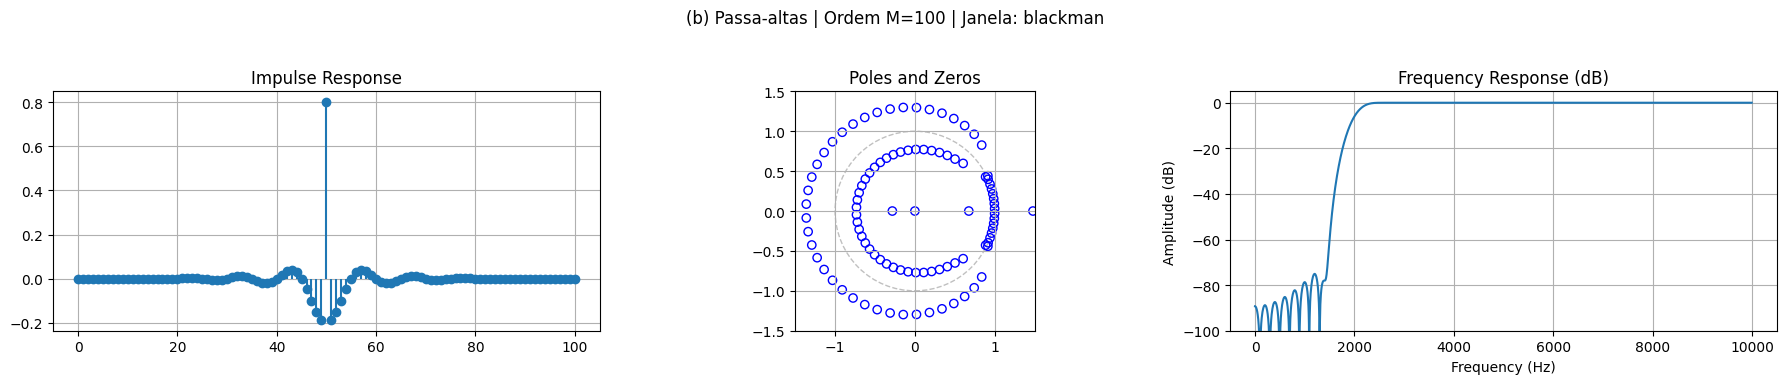


--- Design do filtro: (c) Passa-faixas ---


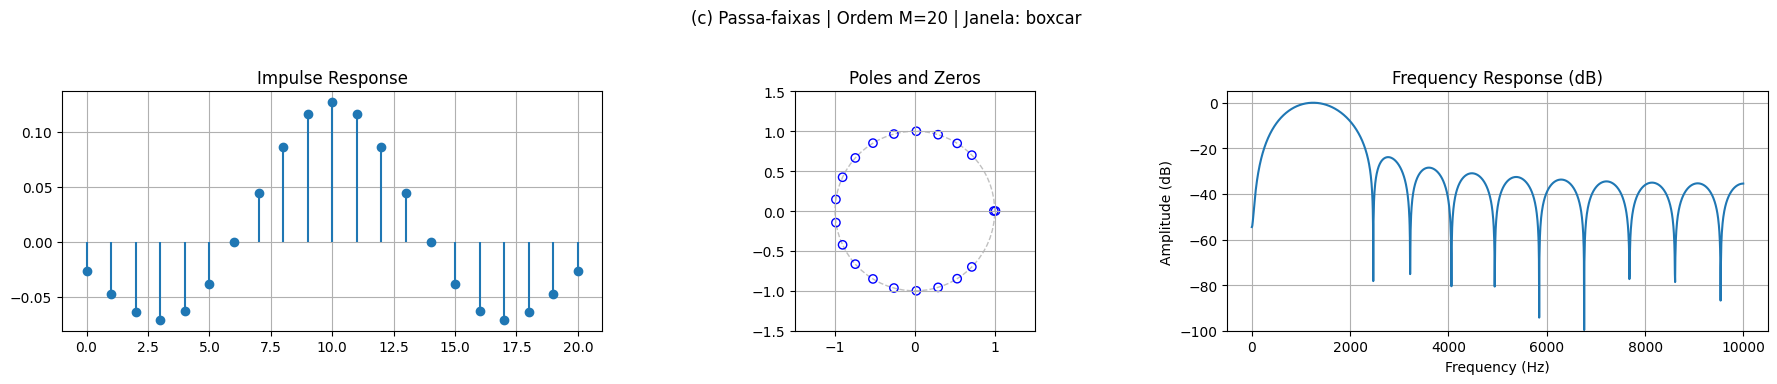

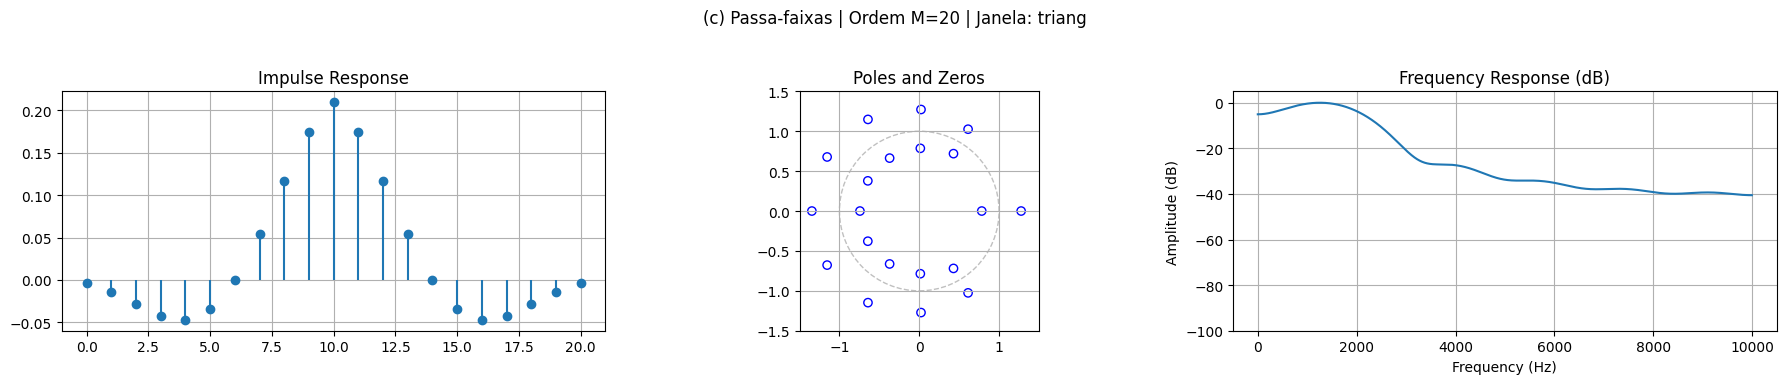

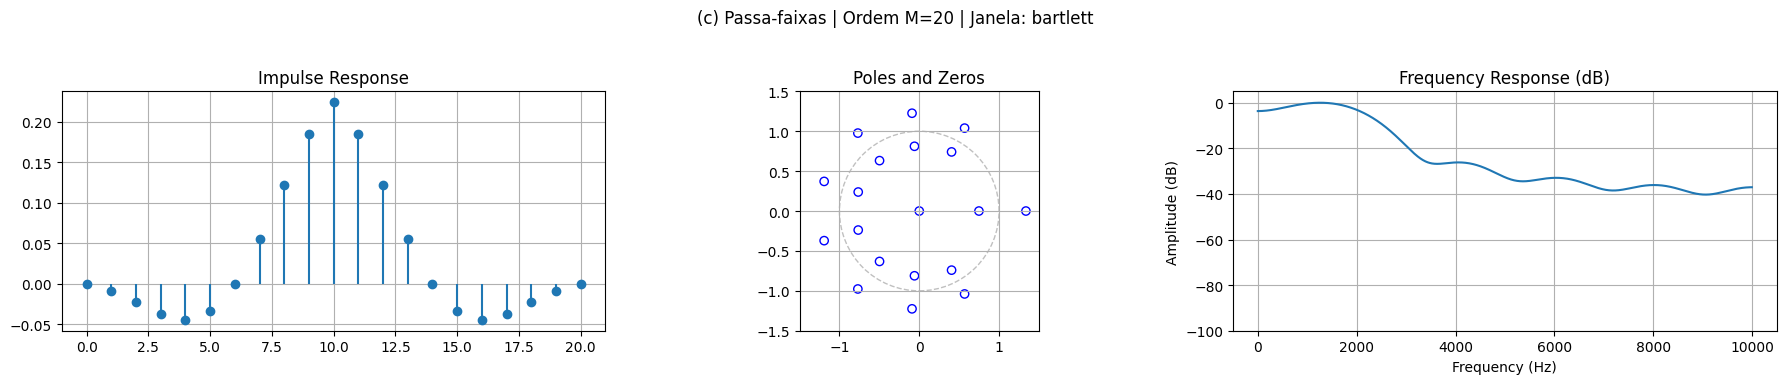

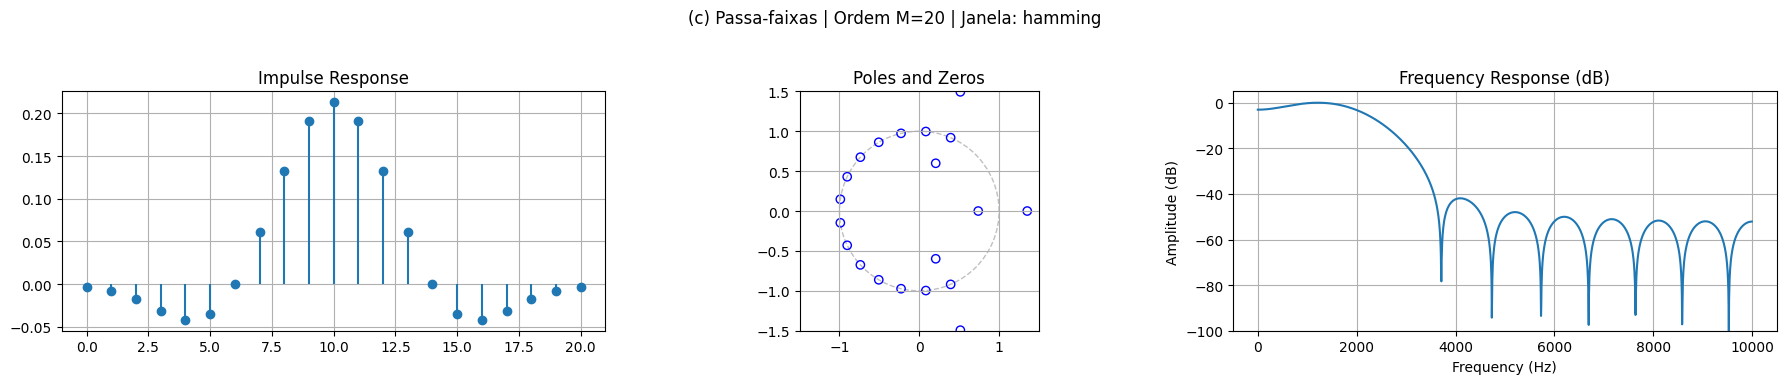

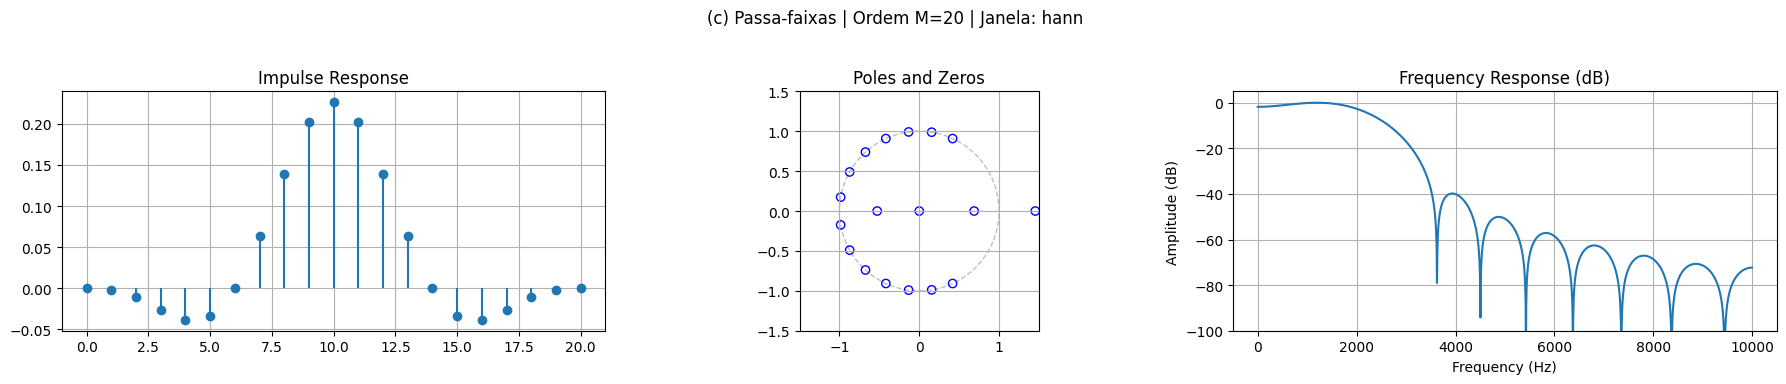

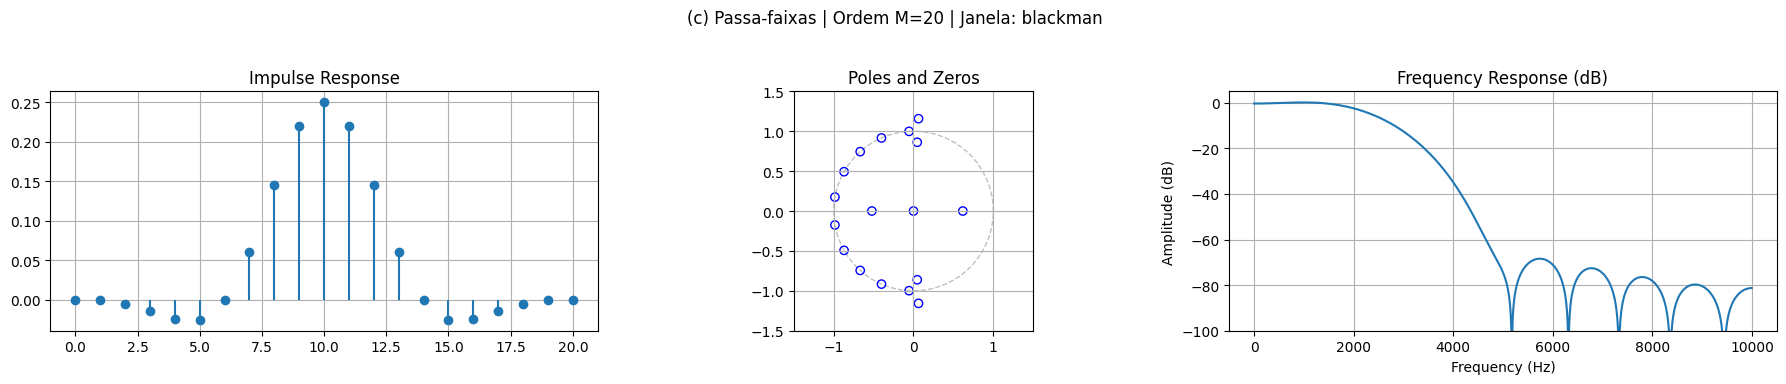

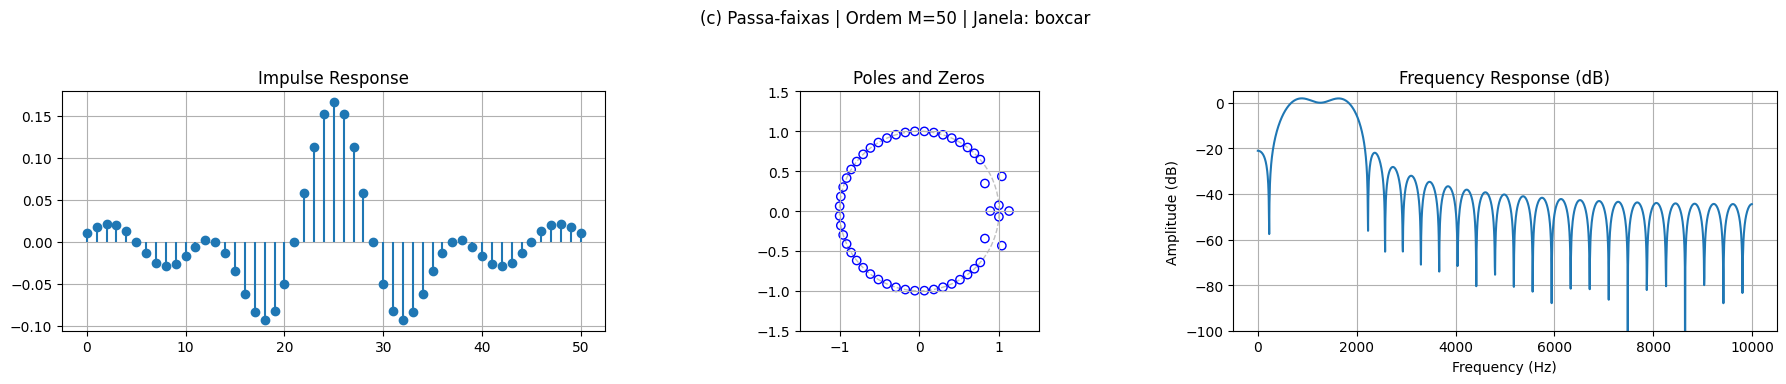

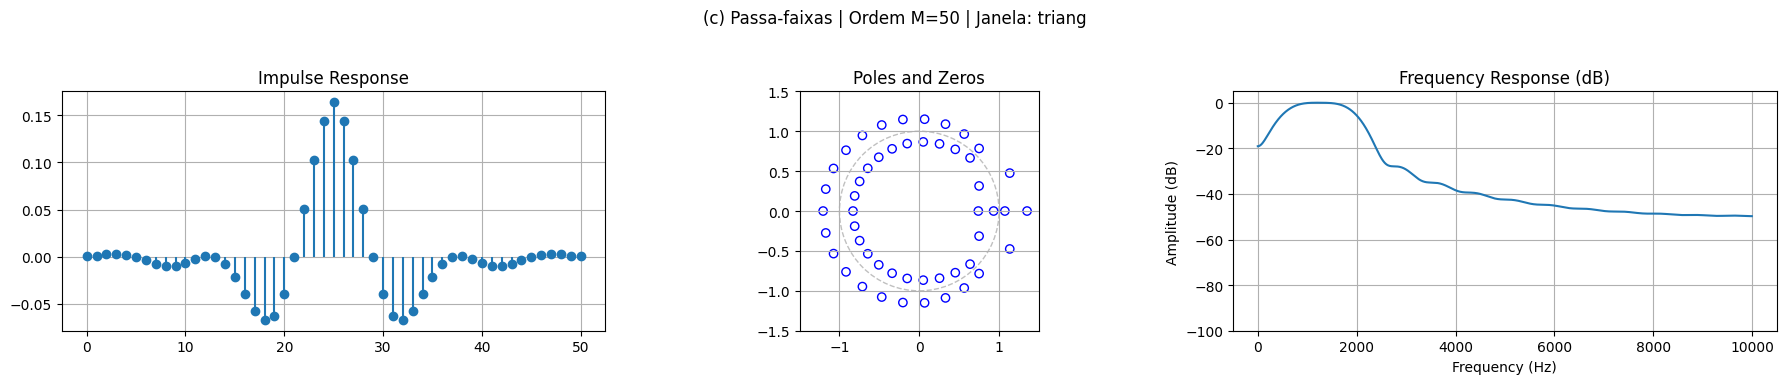

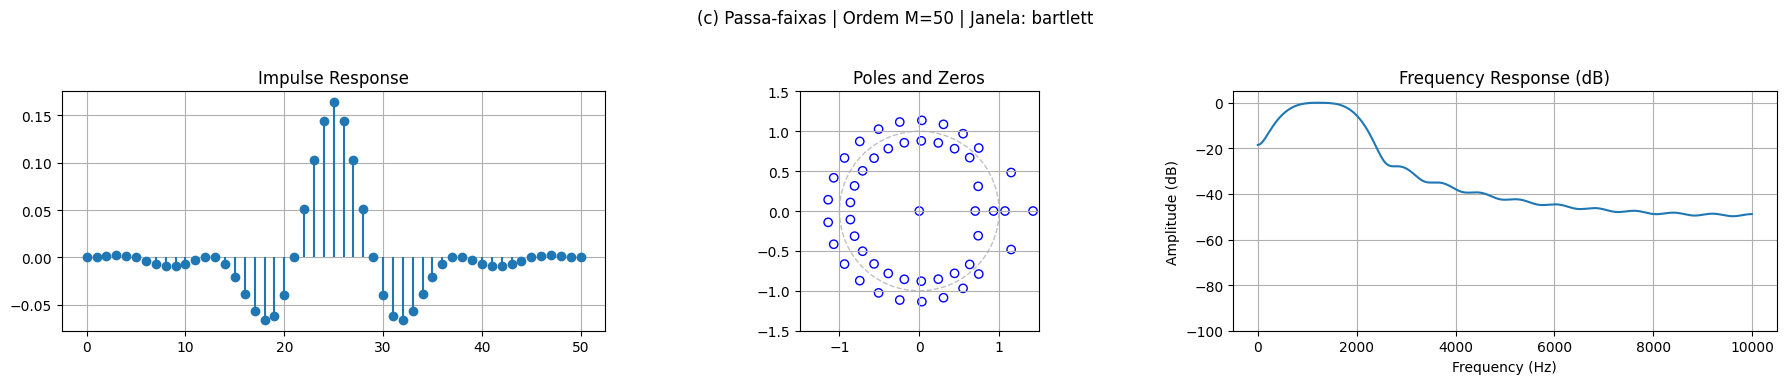

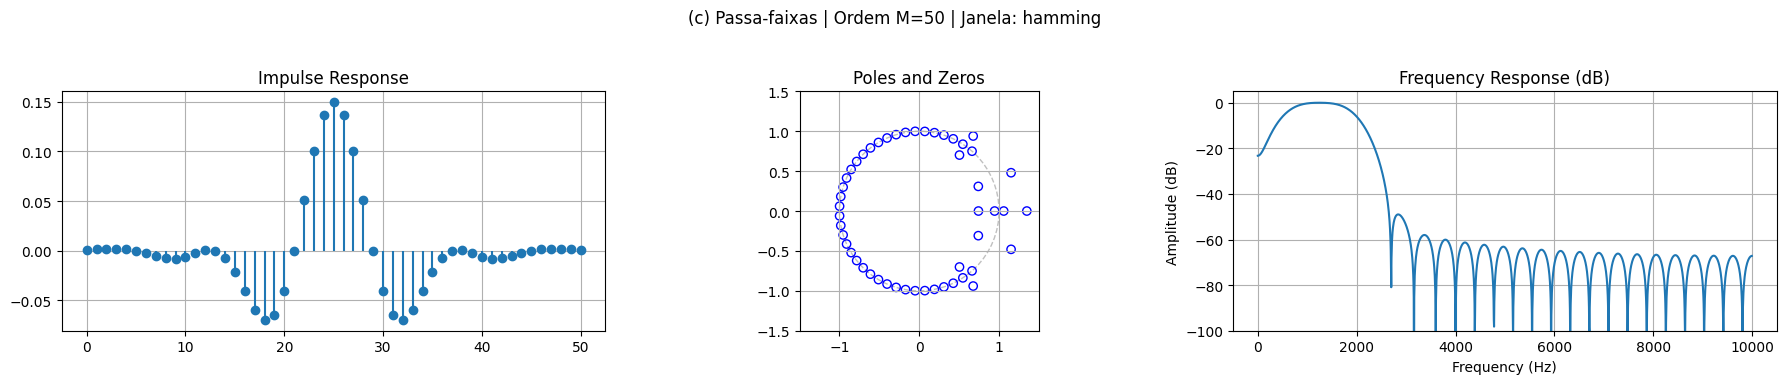

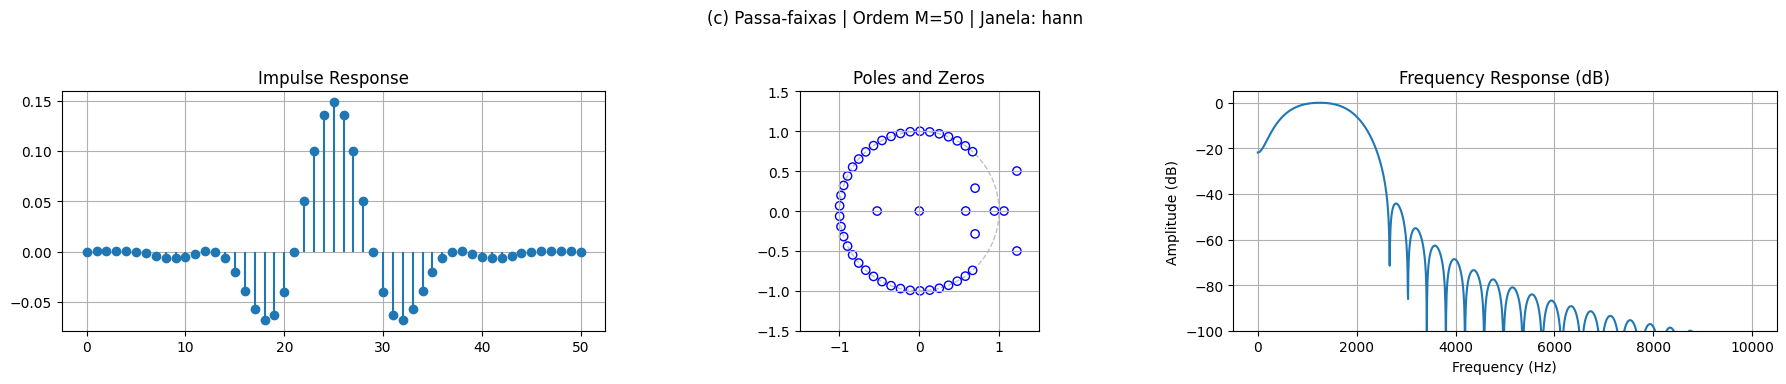

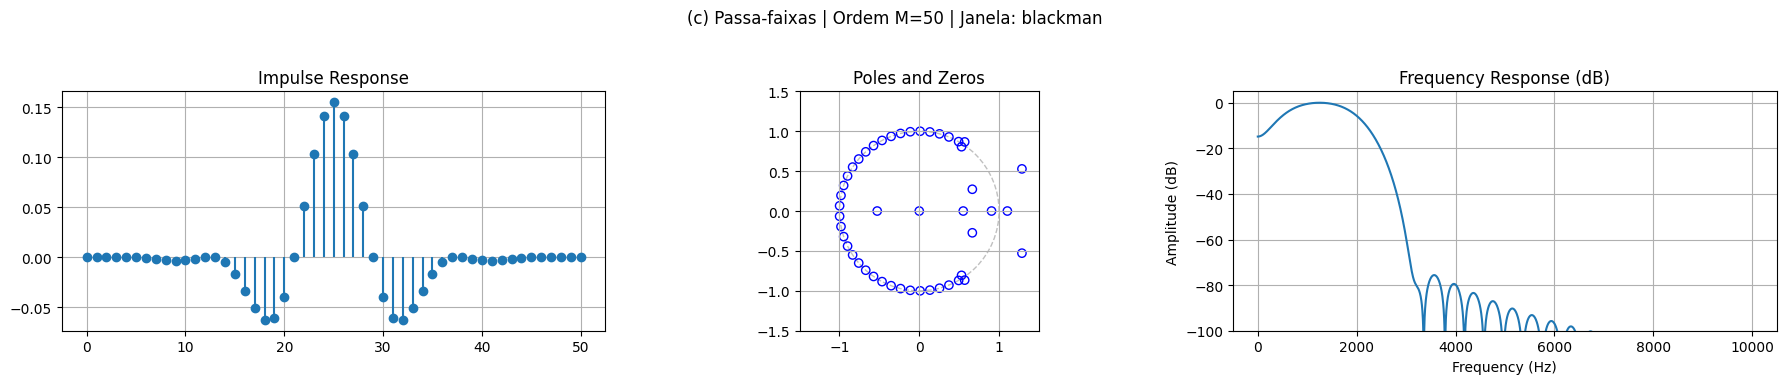

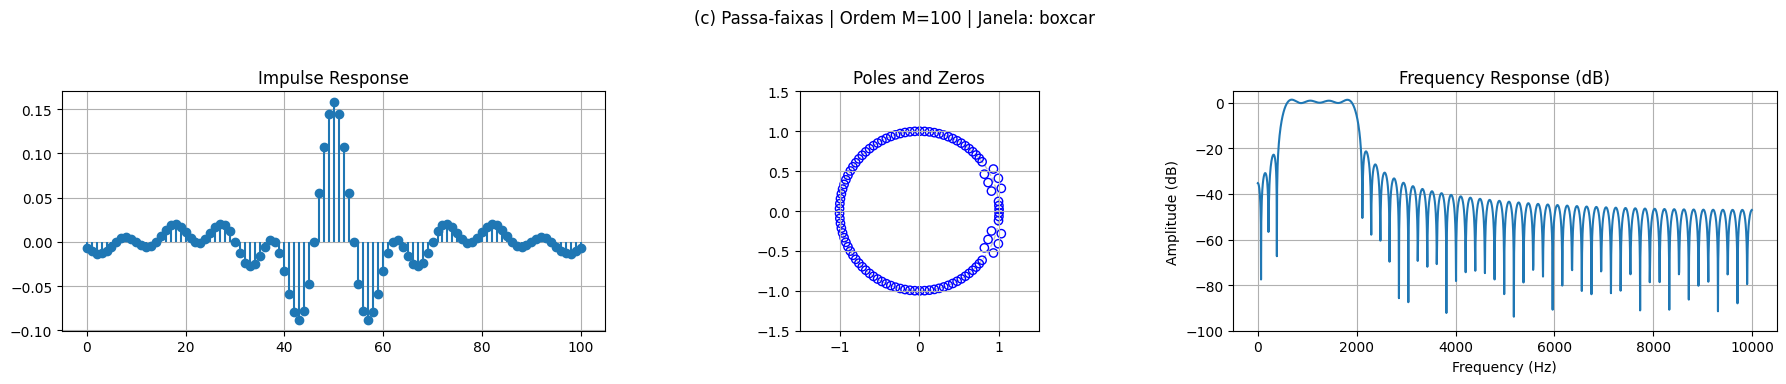

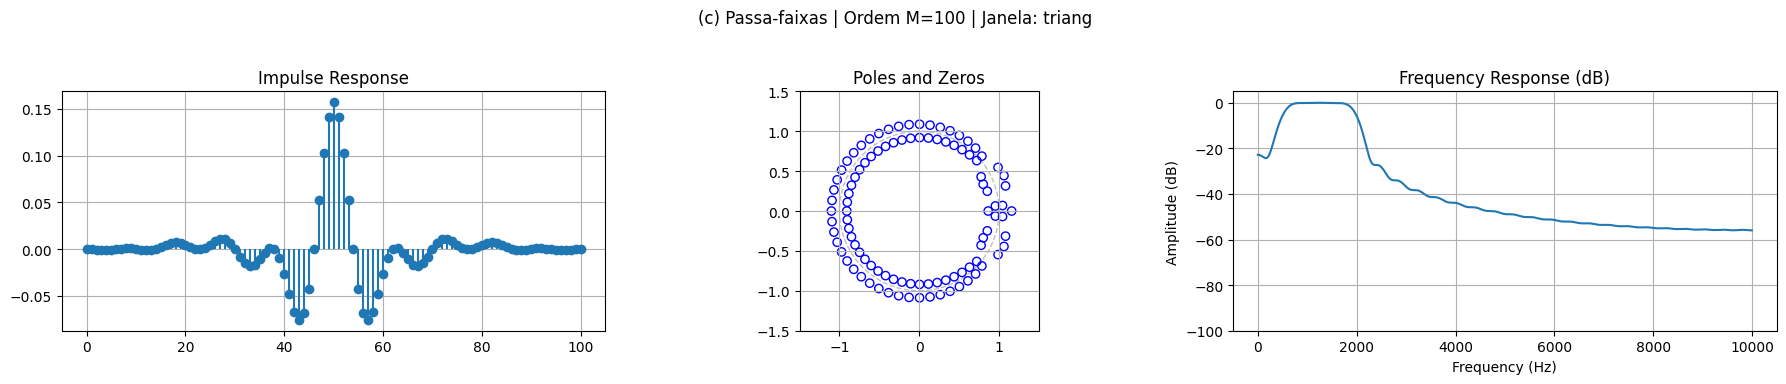

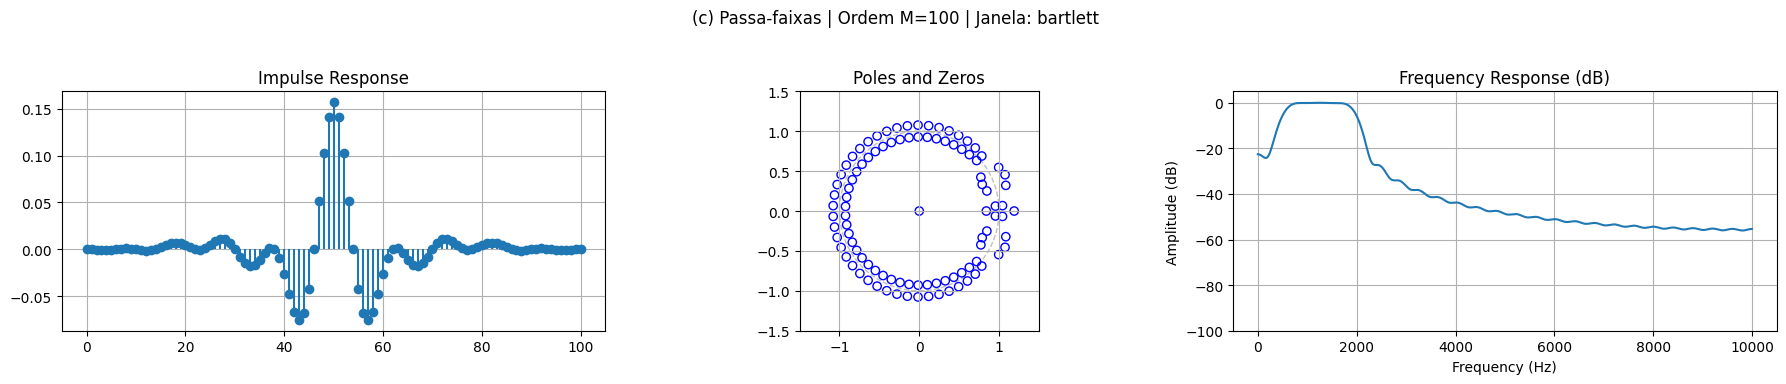

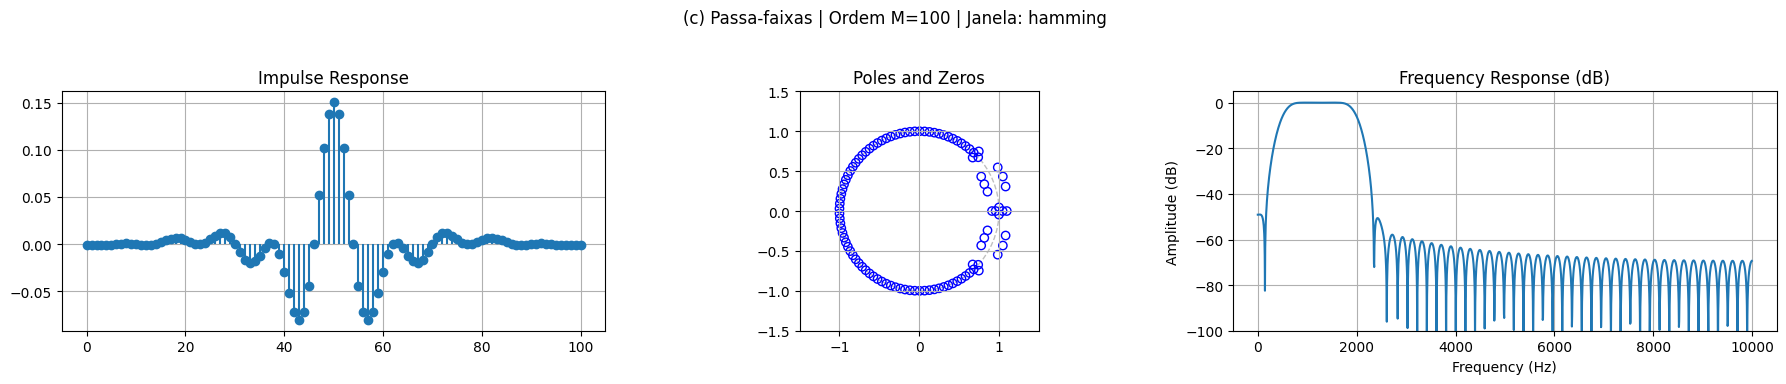

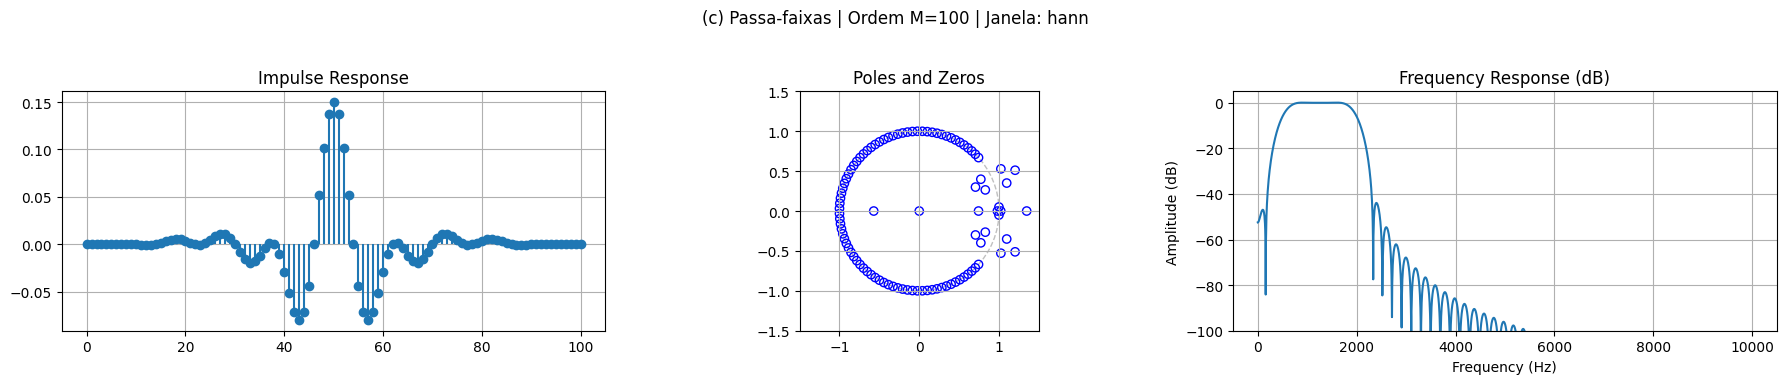

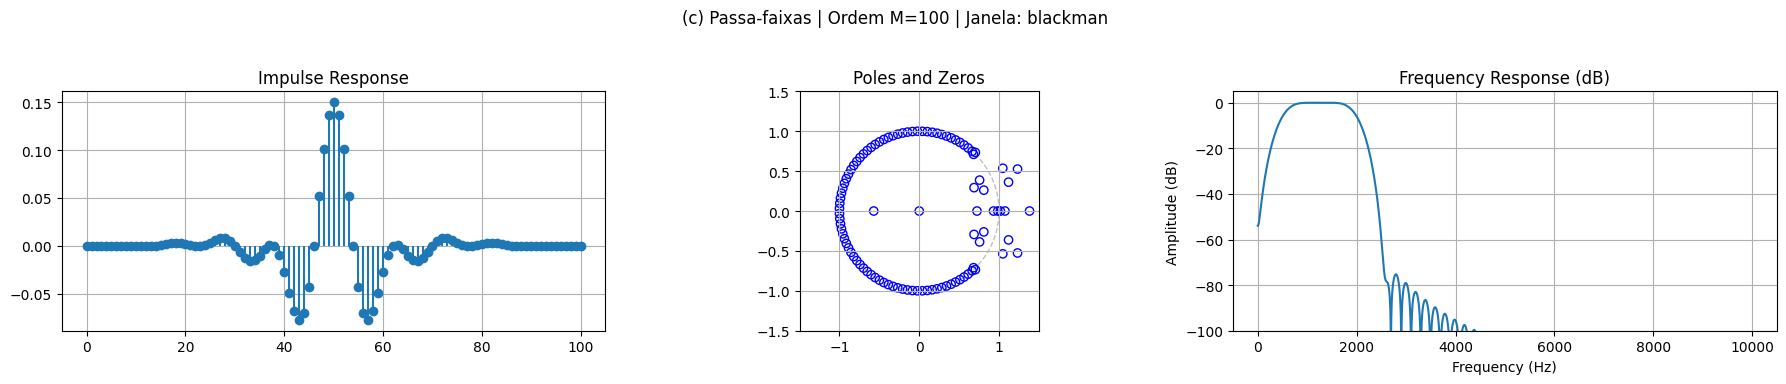


--- Design do filtro: (d) Rejeita-faixas ---


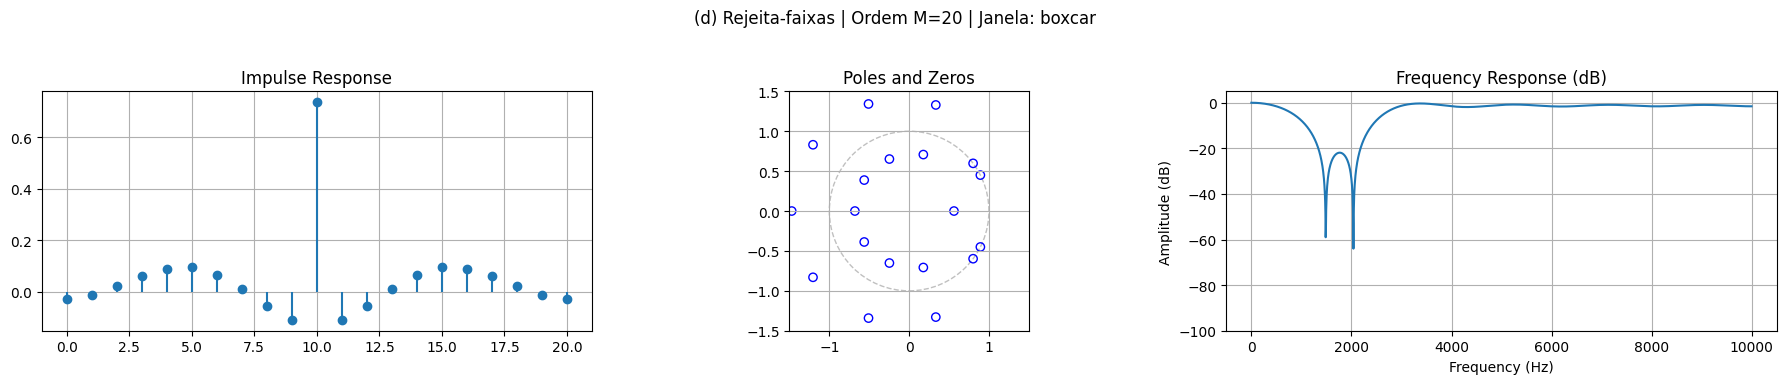

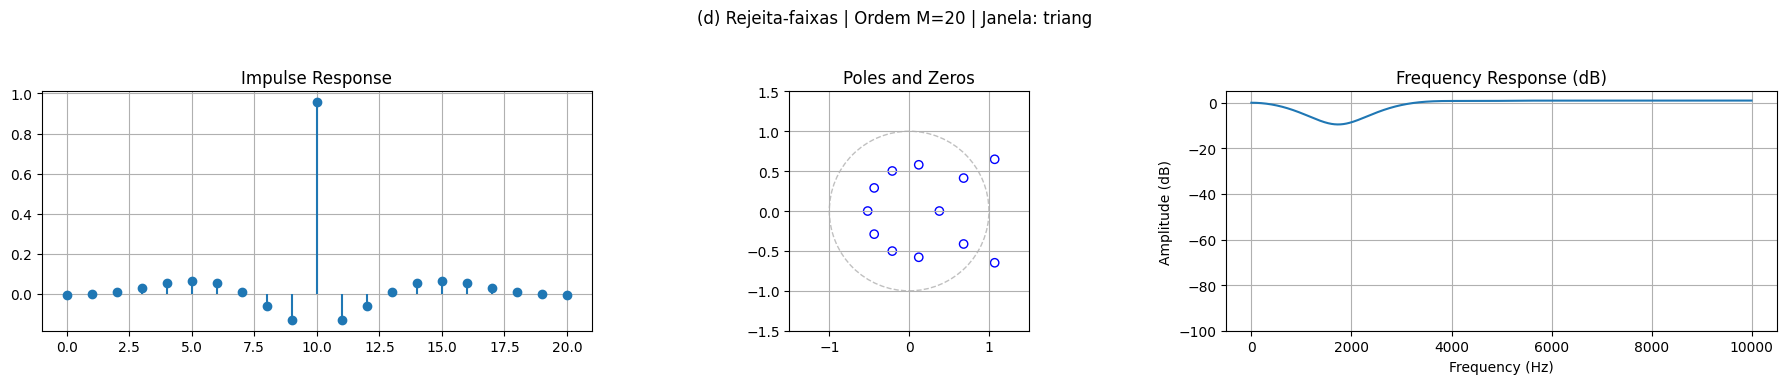

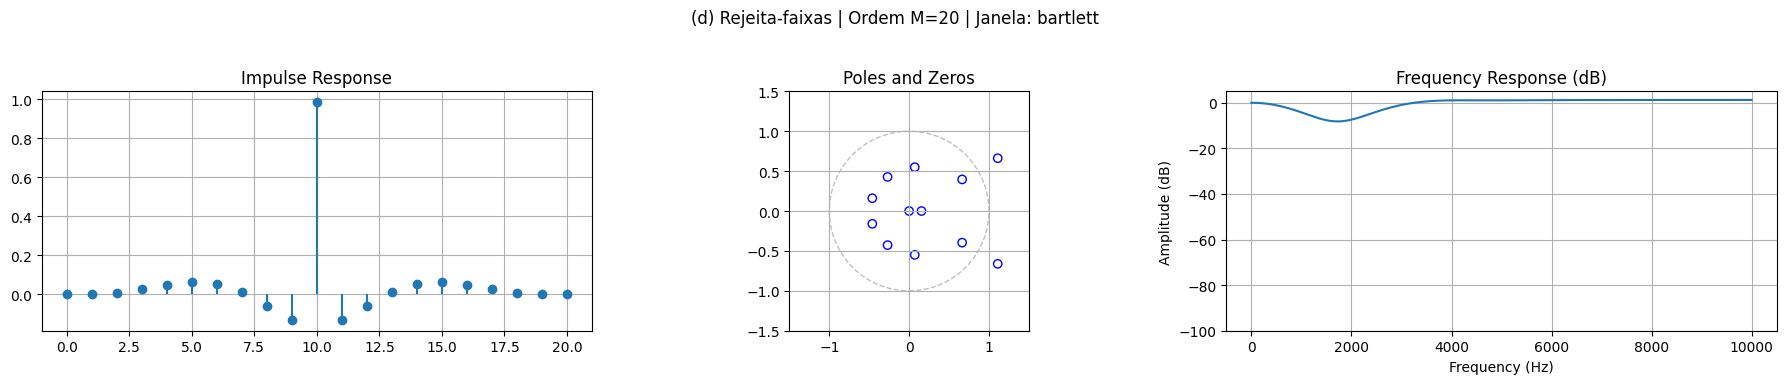

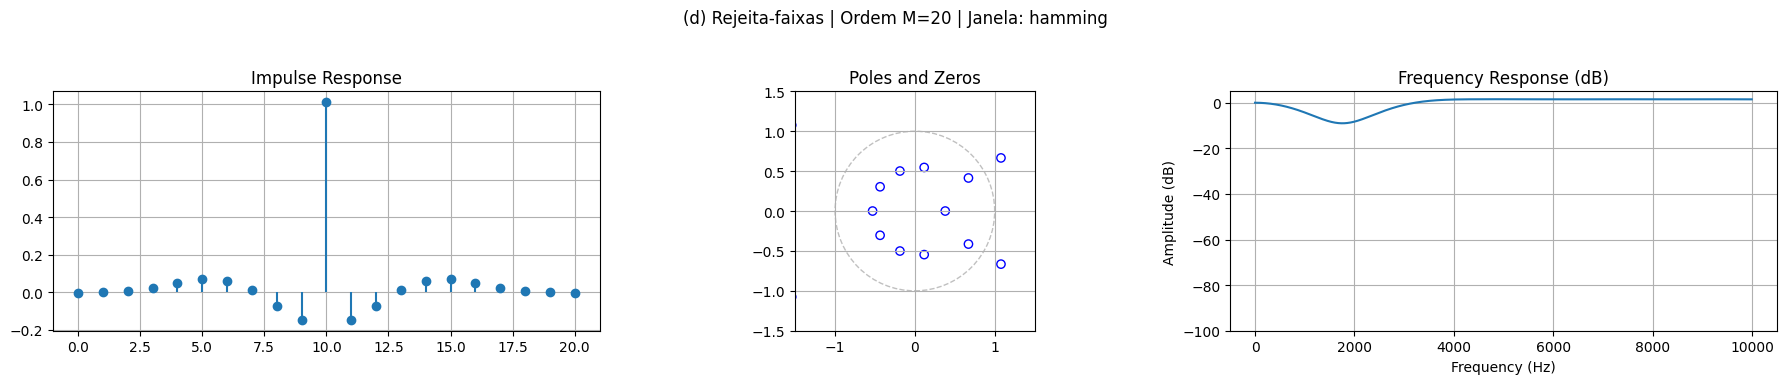

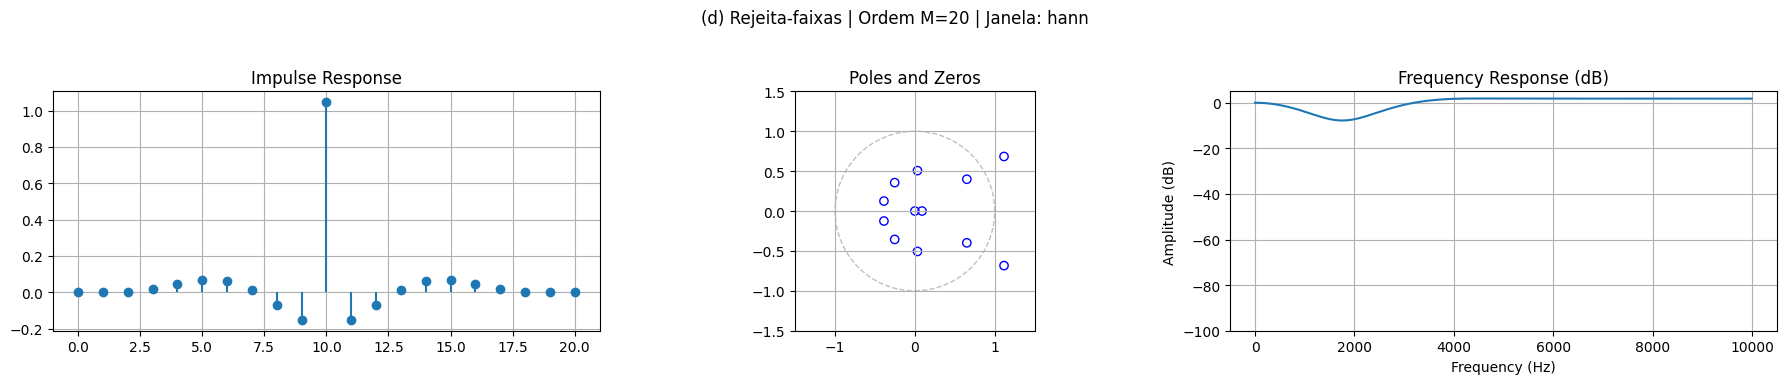

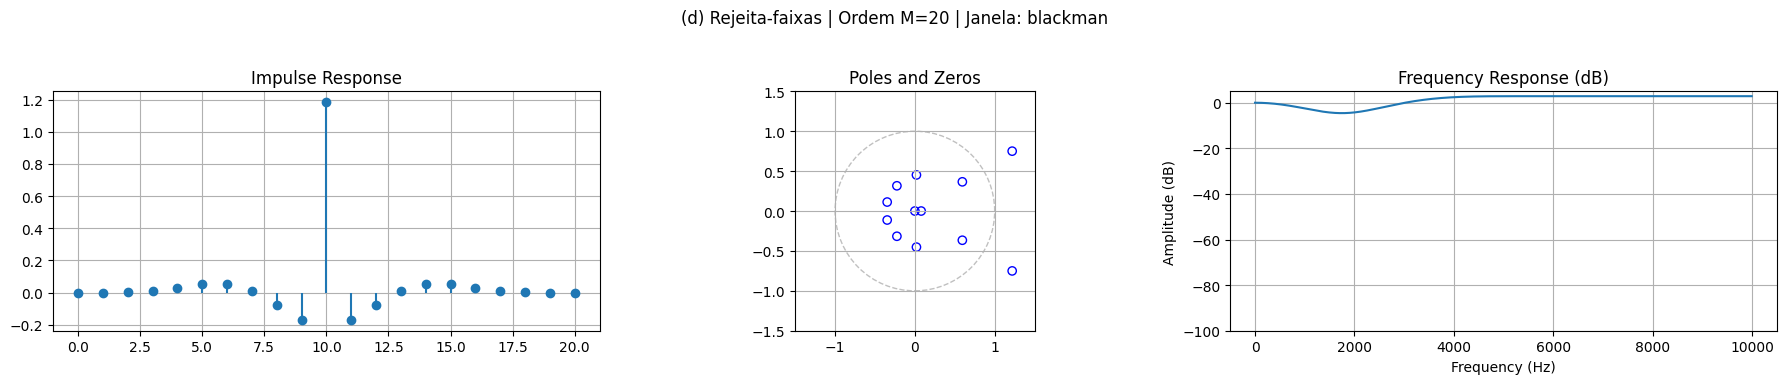

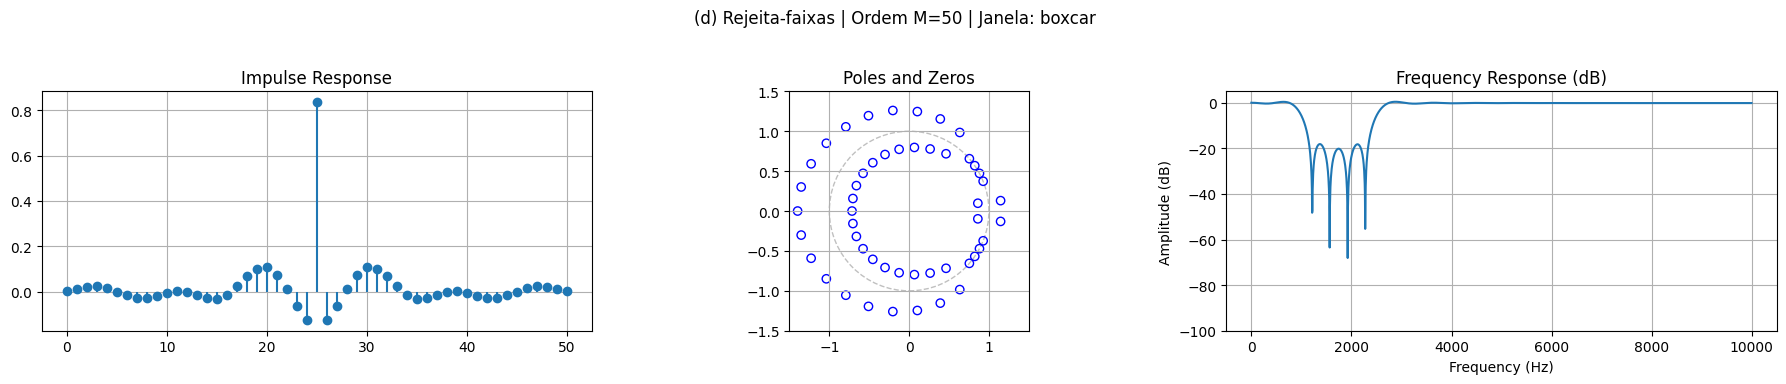

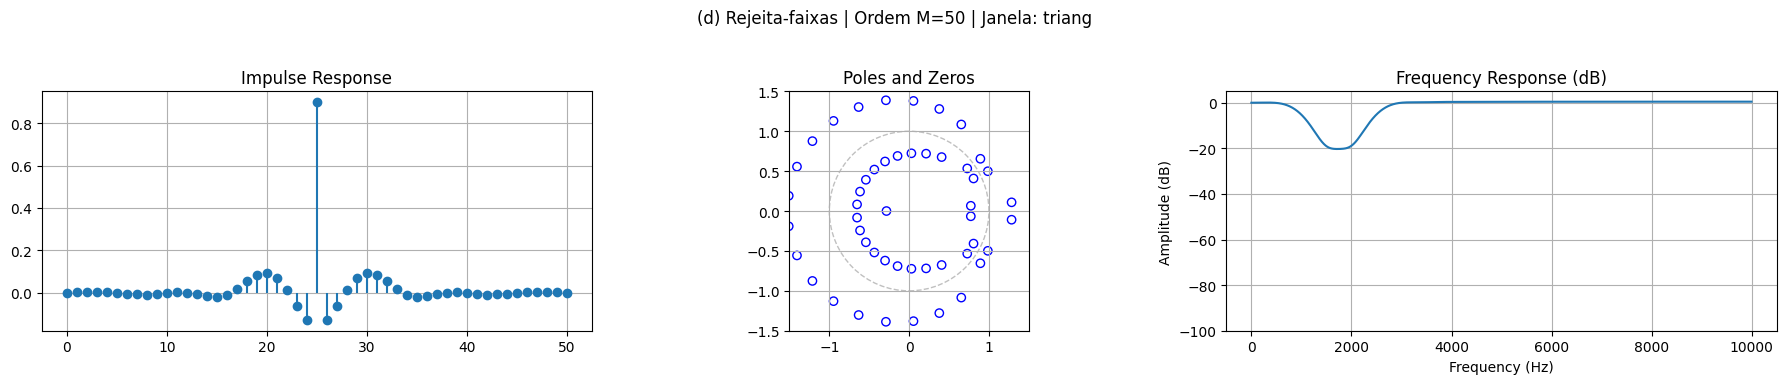

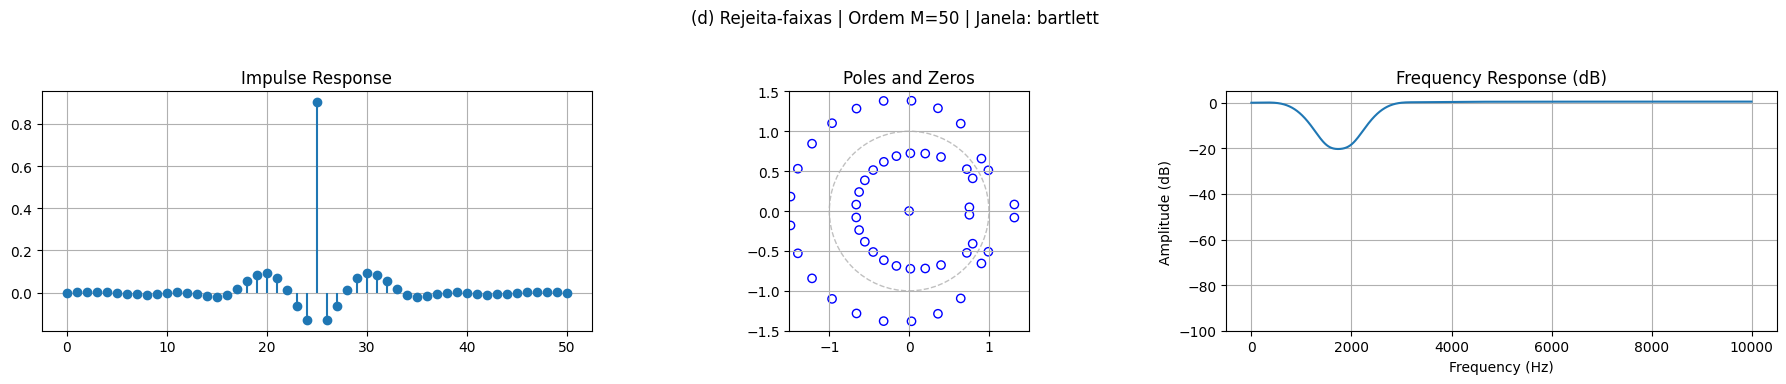

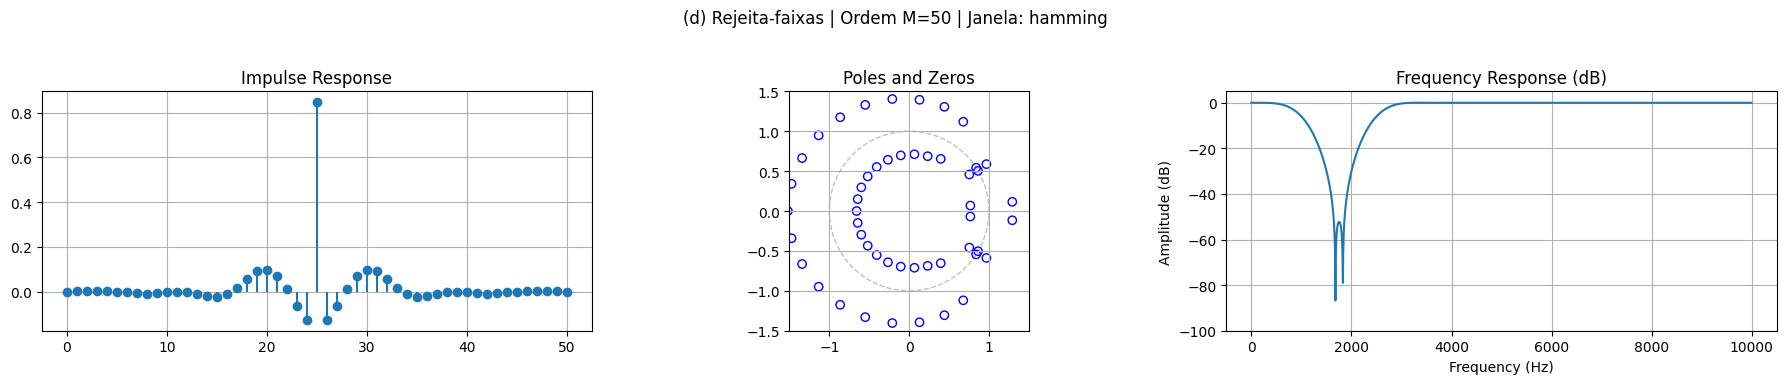

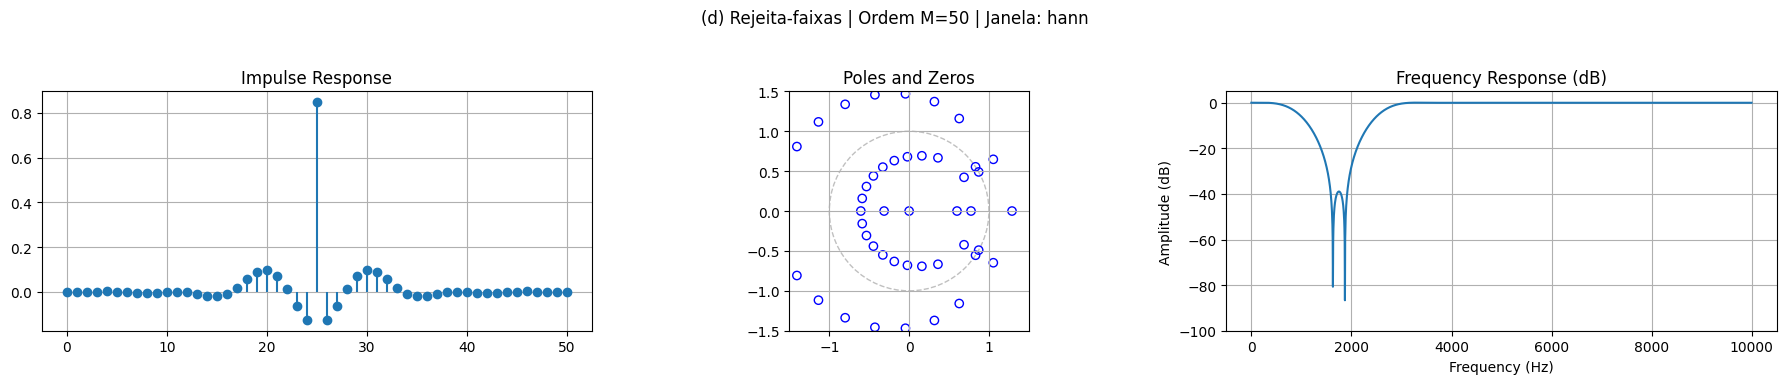

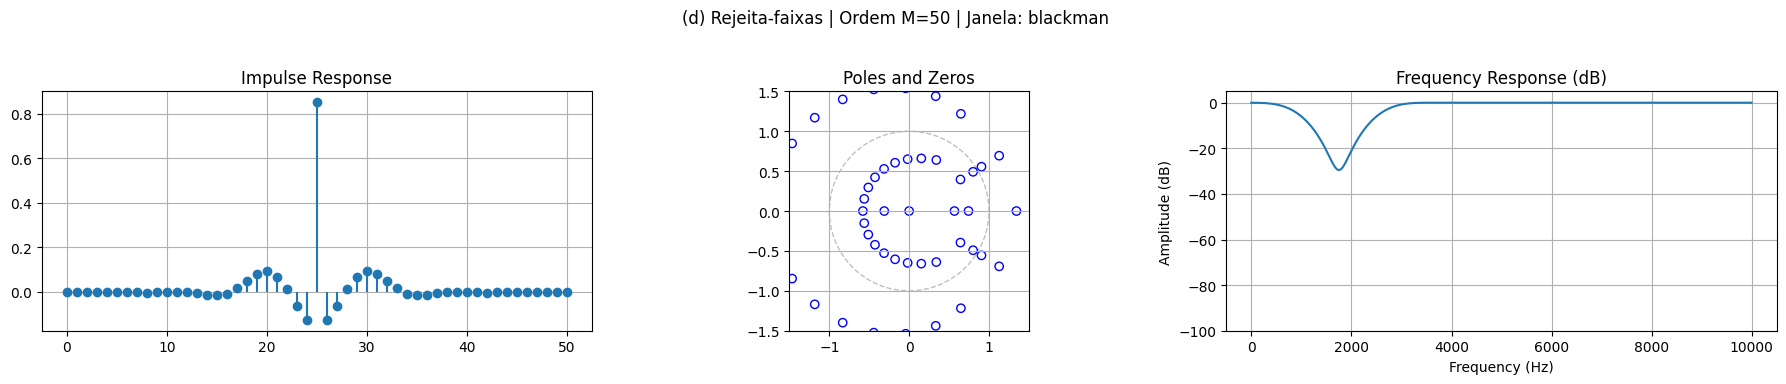

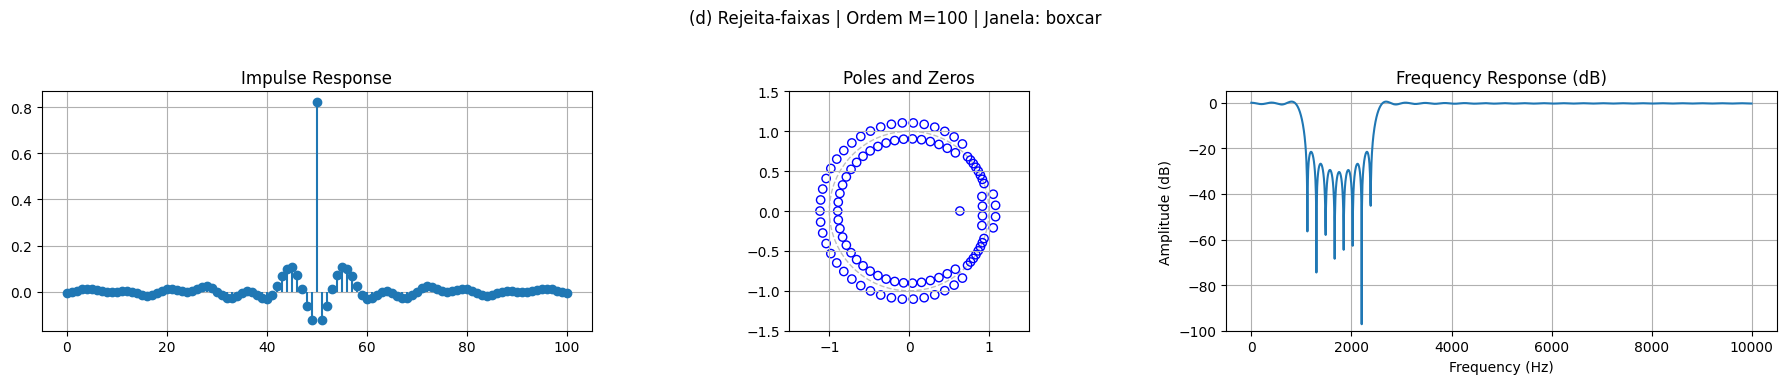

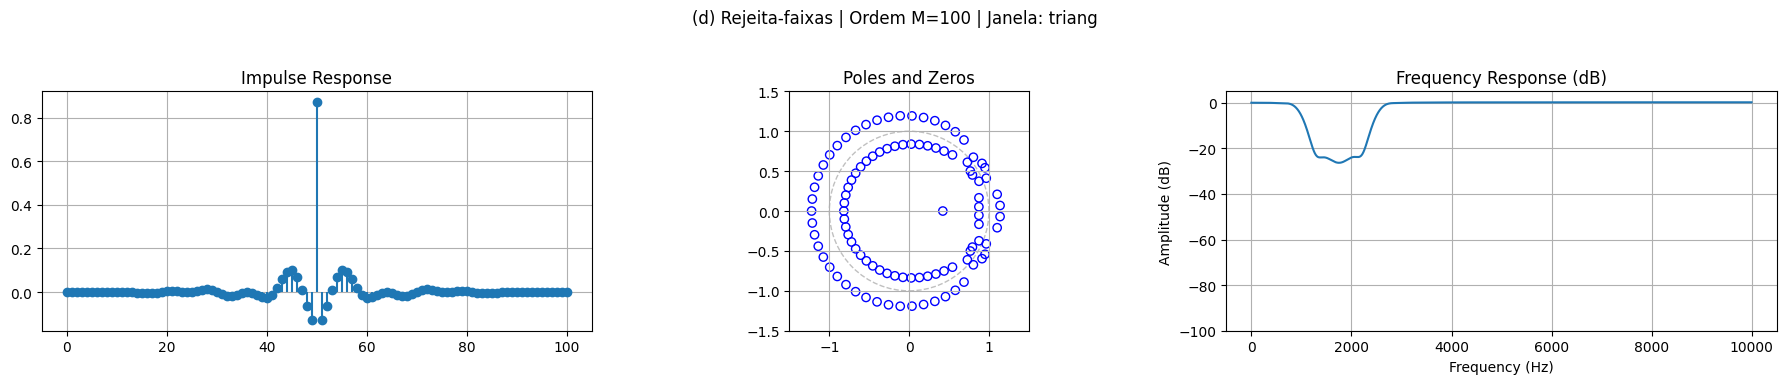

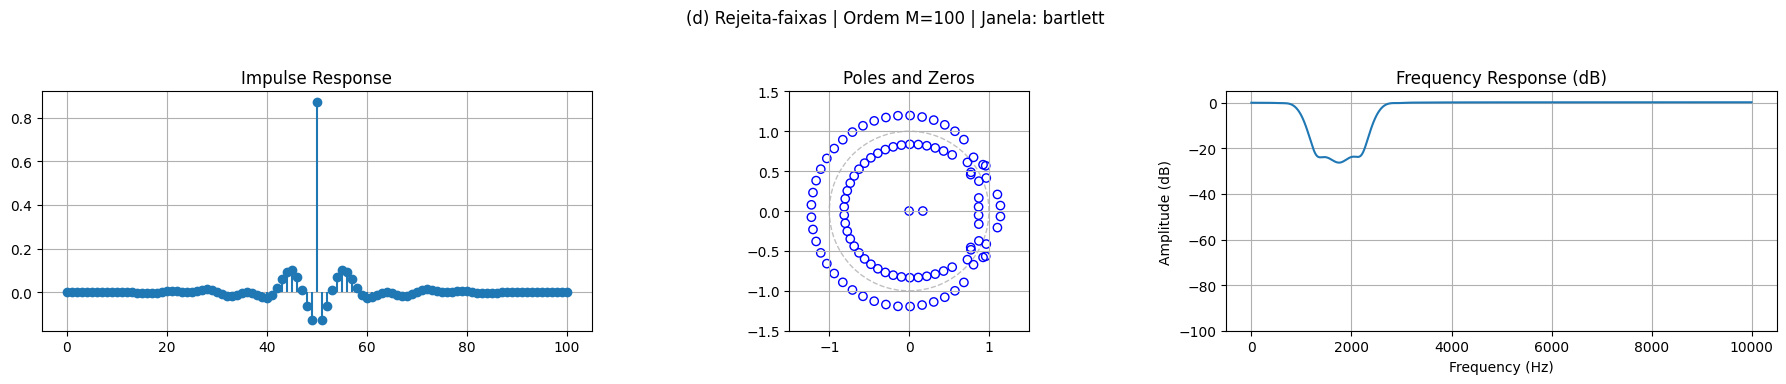

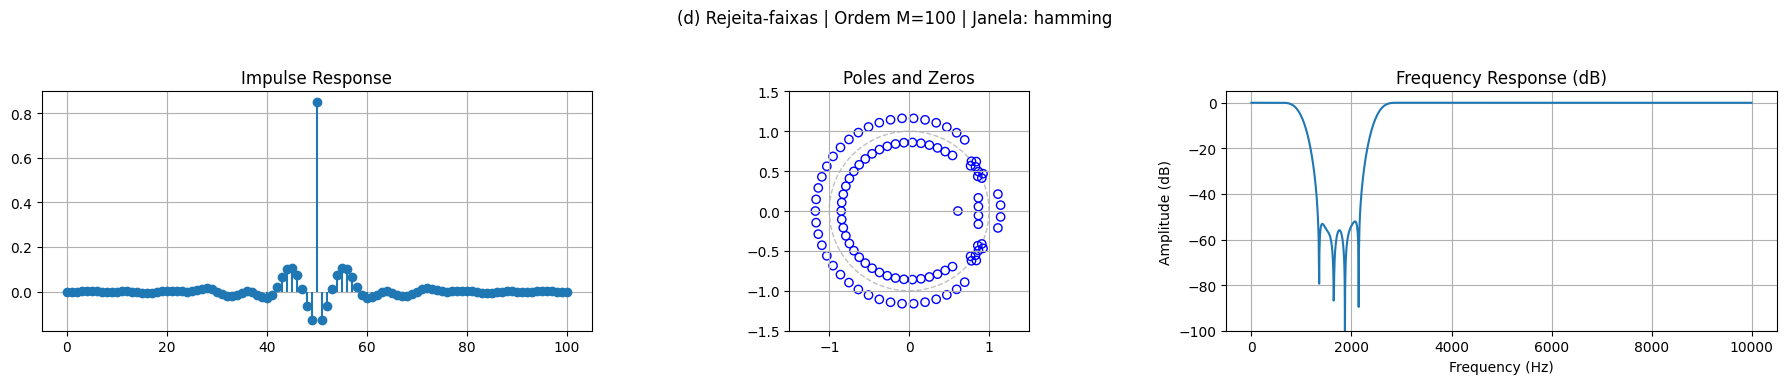

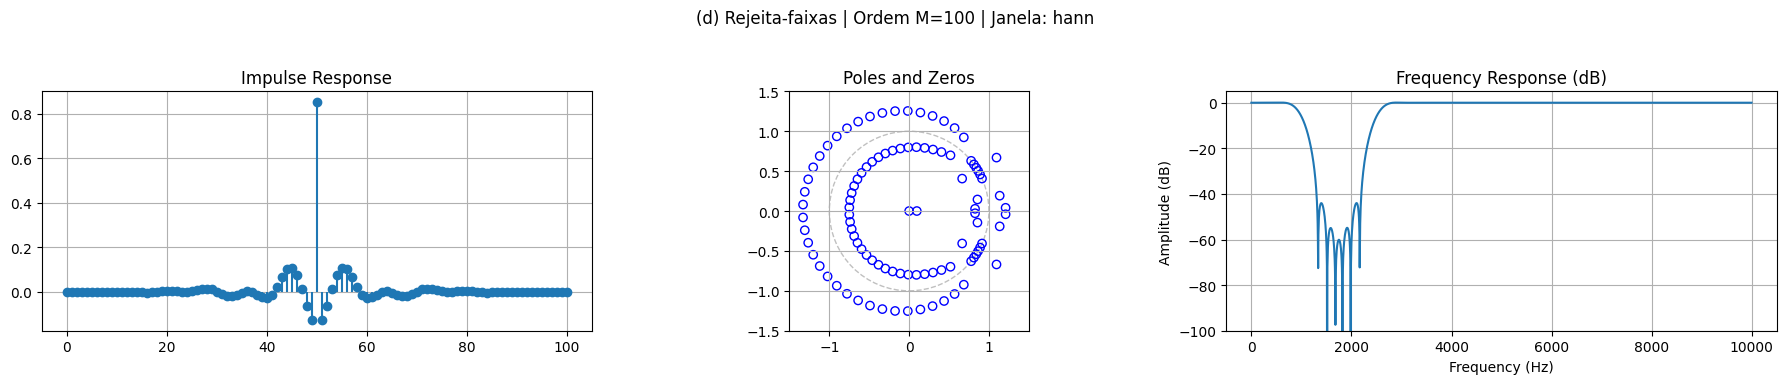

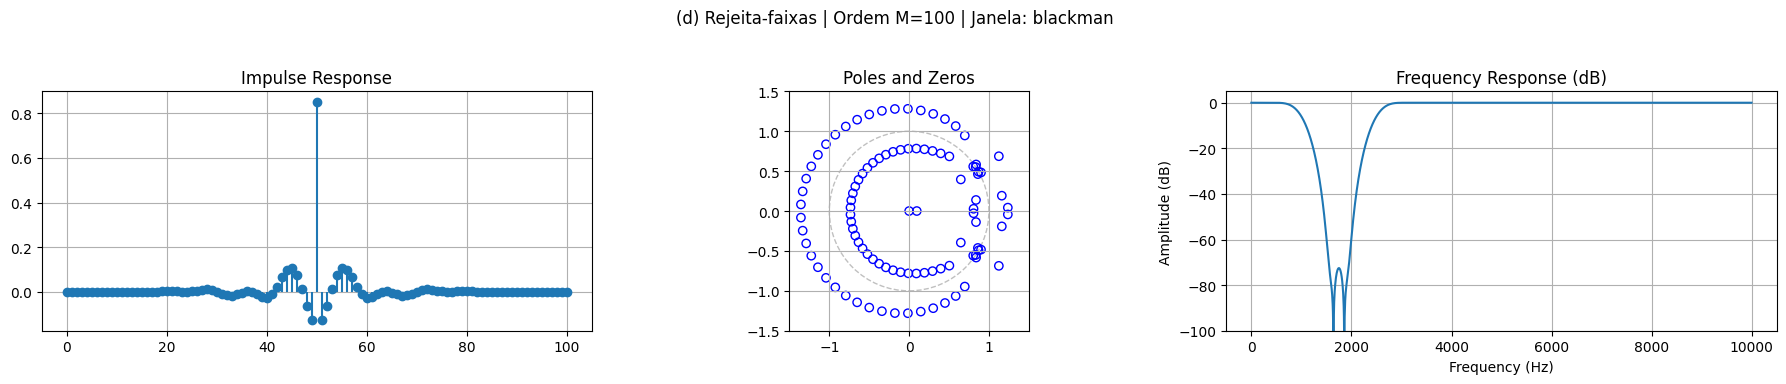


--- Comentários dos Resultados ---
1. Ordem do Filtro (M): À medida que a ordem aumenta, a transição entre a banda de passagem e a de rejeição torna-se mais nítida (slope maior).
2. Efeito das Janelas: A janela retangular possui a transição mais estreita, mas apresenta maior oscilação (Gibbs) e menor atenuação na banda de rejeição. Janelas como Blackman e Hamming suavizam essas oscilações aumentando a atenuação lateral, porém alargando a banda de transição.
3. Estabilidade: Sendo filtros FIR, todos os polos estão na origem (z=0), garantindo estabilidade incondicional.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def plot_filter_properties(b, a, fs, title):
    w, h = signal.freqz(b, a, worN=2000)
    z, p, k = signal.tf2zpk(b, a)

    fig, axs = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(title)

    # Impulse Response
    axs[0].stem(b, basefmt=' ')
    axs[0].set_title('Impulse Response')
    axs[0].grid(True)

    # Pole-Zero Plot
    unit_circle = plt.Circle((0,0), 1, color='silver', fill=False, linestyle='--')
    axs[1].add_artist(unit_circle)
    axs[1].scatter(np.real(z), np.imag(z), marker='o', edgecolors='b', facecolors='none', label='Zeros')
    axs[1].scatter(np.real(p), np.imag(p), marker='x', color='r', label='Poles')
    axs[1].set_title('Poles and Zeros')
    axs[1].set_xlim([-1.5, 1.5])
    axs[1].set_ylim([-1.5, 1.5])
    axs[1].set_aspect('equal')
    axs[1].grid(True)

    # Frequency Response
    axs[2].plot(0.5*fs*w/np.pi, 20 * np.log10(abs(h)))
    axs[2].set_title('Frequency Response (dB)')
    axs[2].set_xlabel('Frequency (Hz)')
    axs[2].set_ylabel('Amplitude (dB)')
    axs[2].set_ylim([-100, 5])
    axs[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

fs = 20000
orders = [20, 50, 100]
windows = ['boxcar', 'triang', 'bartlett', 'hamming', 'hann', 'blackman']

filters = [
    {'name': '(a) Passa-baixas', 'type': 'lowpass', 'cutoff': [1000]},
    {'name': '(b) Passa-altas', 'type': 'highpass', 'cutoff': [2000]},
    {'name': '(c) Passa-faixas', 'type': 'bandpass', 'cutoff': [500, 2000]},
    {'name': '(d) Rejeita-faixas', 'type': 'bandstop', 'cutoff': [1000, 2500]}
]

for filt in filters:
    print(f"\n--- Design do filtro: {filt['name']} ---")
    for M in orders:
        num_taps = M + 1
        for win in windows:
            # Design FIR filter using window method
            b = signal.firwin(num_taps, filt['cutoff'], fs=fs, pass_zero=filt['type'], window=win)
            plot_filter_properties(b, [1.0], fs, f"{filt['name']} | Ordem M={M} | Janela: {win}")

print("\n--- Comentários dos Resultados ---\n"
      "1. Ordem do Filtro (M): À medida que a ordem aumenta, a transição entre a banda de passagem e a de rejeição torna-se mais nítida (slope maior).\n"
      "2. Efeito das Janelas: A janela retangular possui a transição mais estreita, mas apresenta maior oscilação (Gibbs) e menor atenuação na banda de rejeição. "
      "Janelas como Blackman e Hamming suavizam essas oscilações aumentando a atenuação lateral, porém alargando a banda de transição.\n"
      "3. Estabilidade: Sendo filtros FIR, todos os polos estão na origem (z=0), garantindo estabilidade incondicional.")

### Questão 2: Filtro Baseado na Resposta em Frequência da Imagem

Com base na imagem (típica de filtros multi-banda), derivamos a resposta ao impulso ideal. Supondo um filtro com bandas definidas, a resposta ideal é dada por:

$$h_d[n] = \frac{\sin(\omega_{c2}(n-M/2))}{\pi(n-M/2)} - \frac{\sin(\omega_{c1}(n-M/2))}{\pi(n-M/2)}$$

(Ajustaremos as frequências de corte de acordo com a análise visual do gráfico).

/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


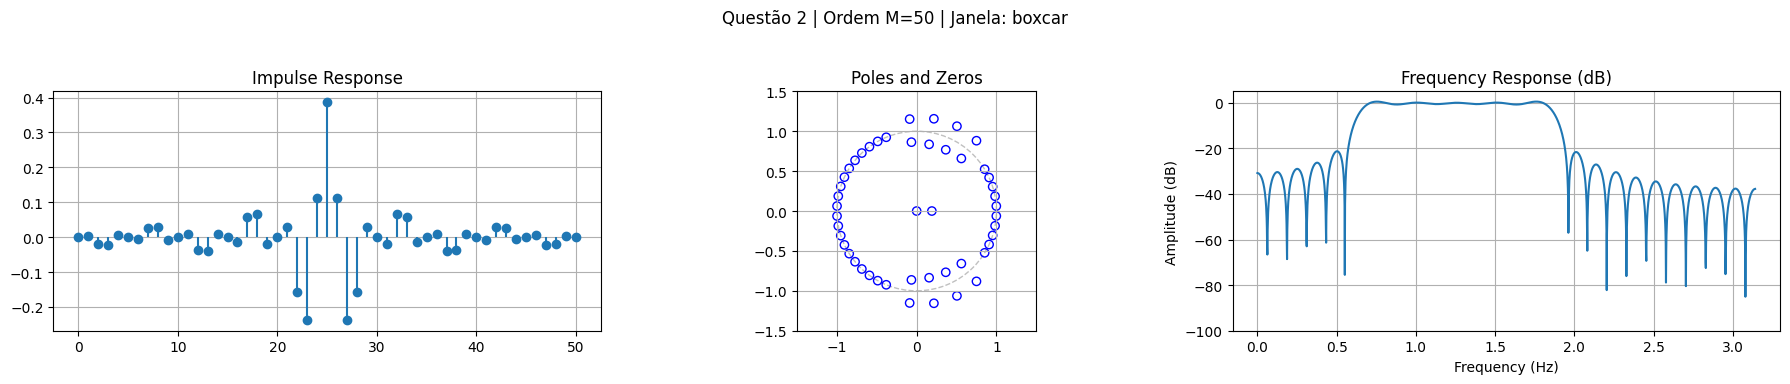

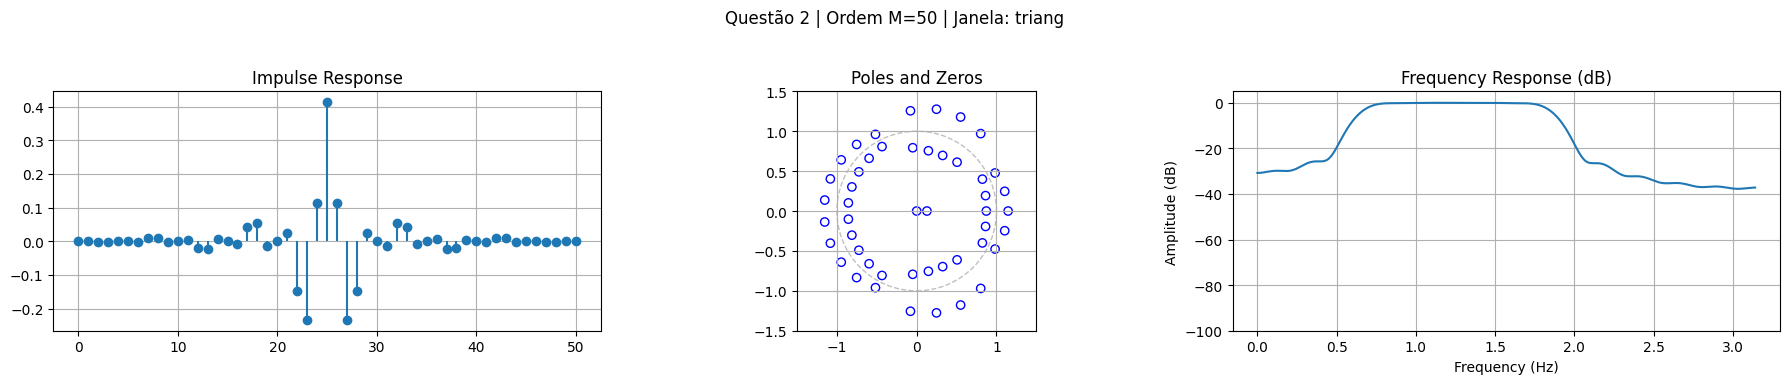

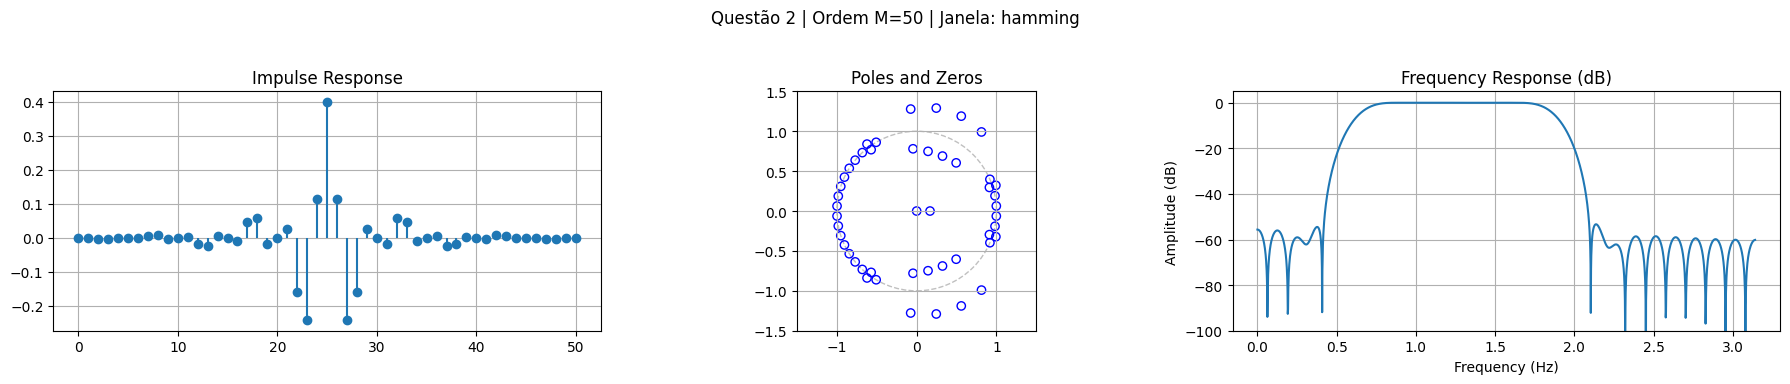

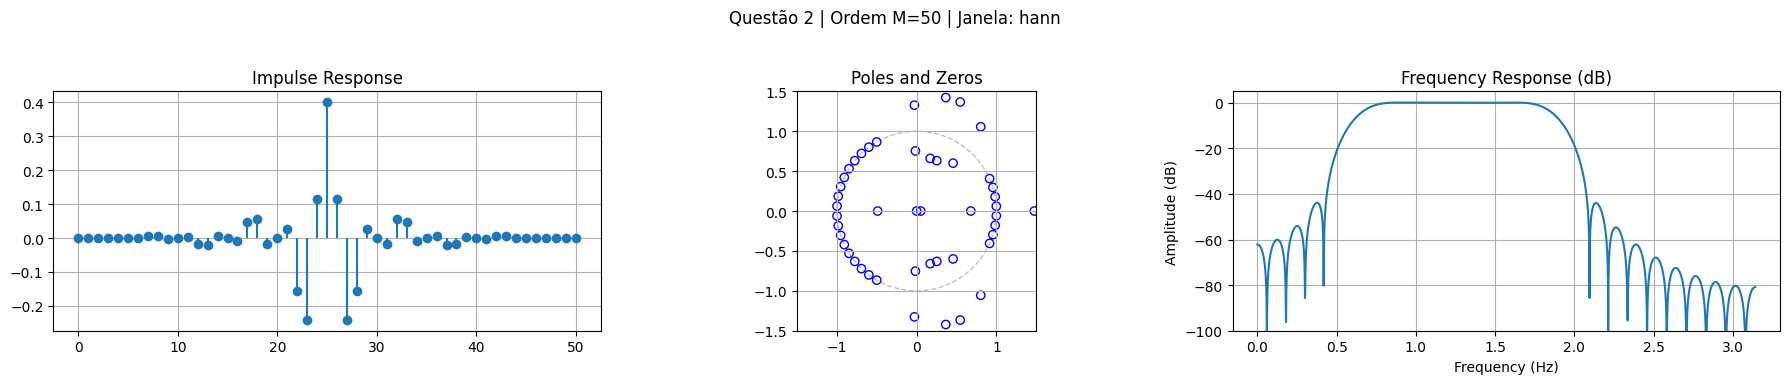

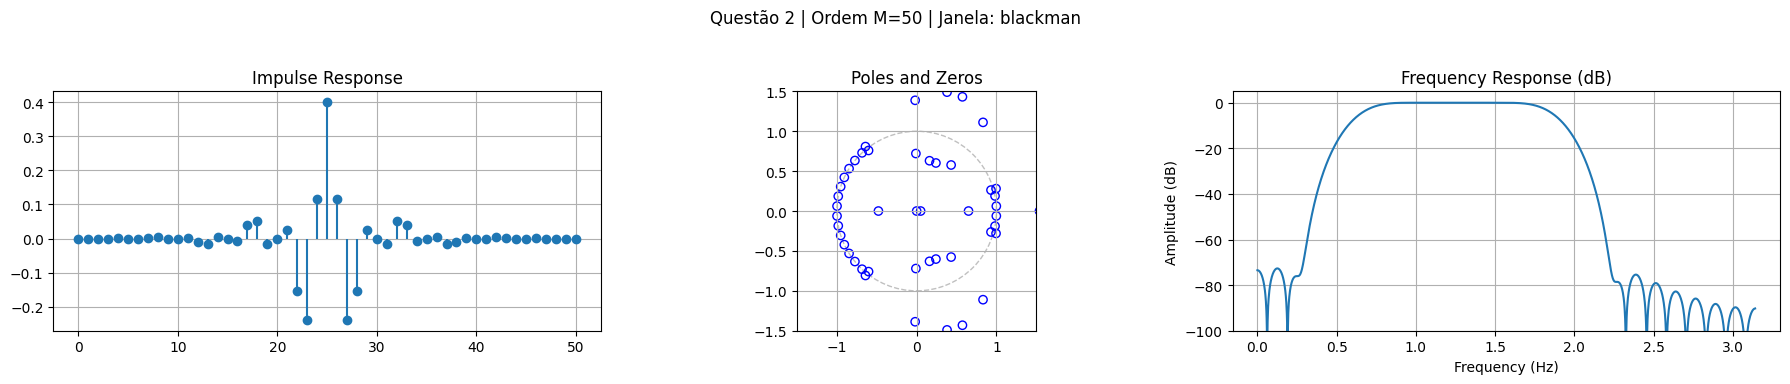

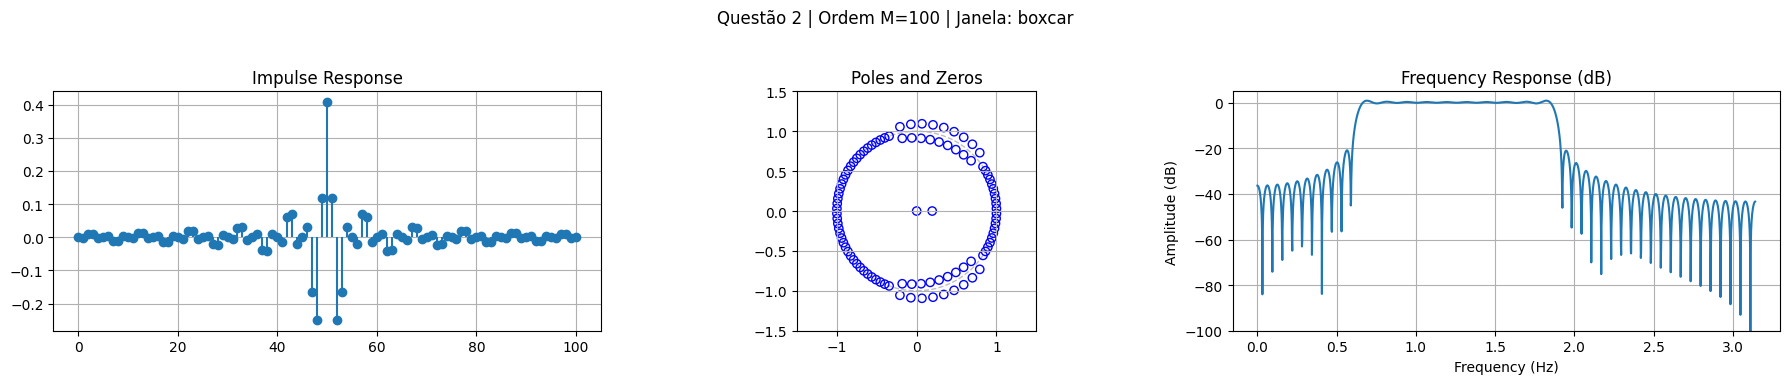

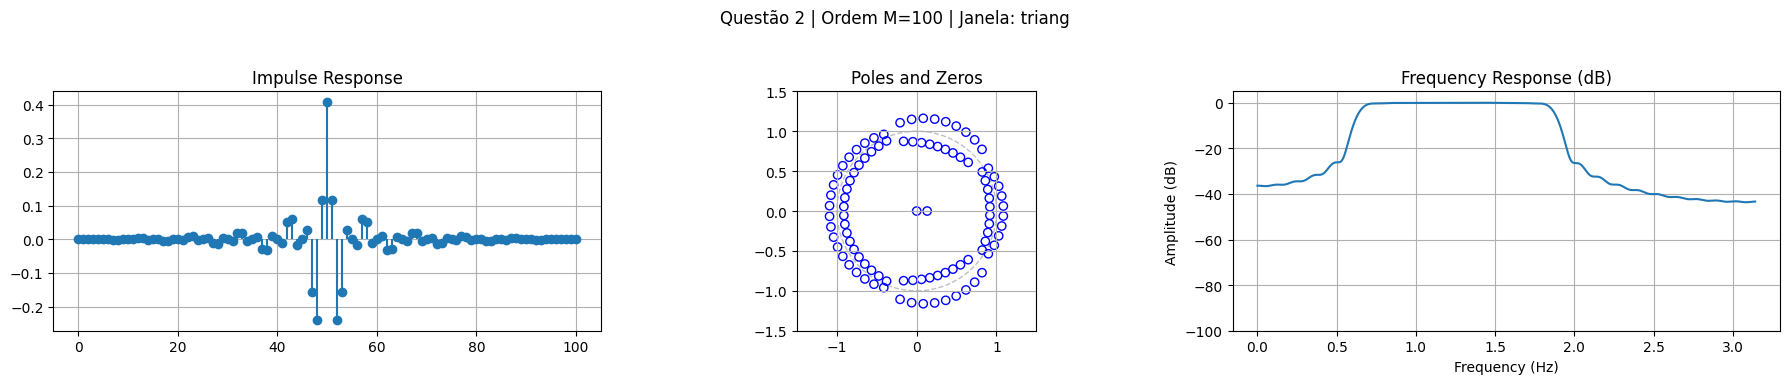

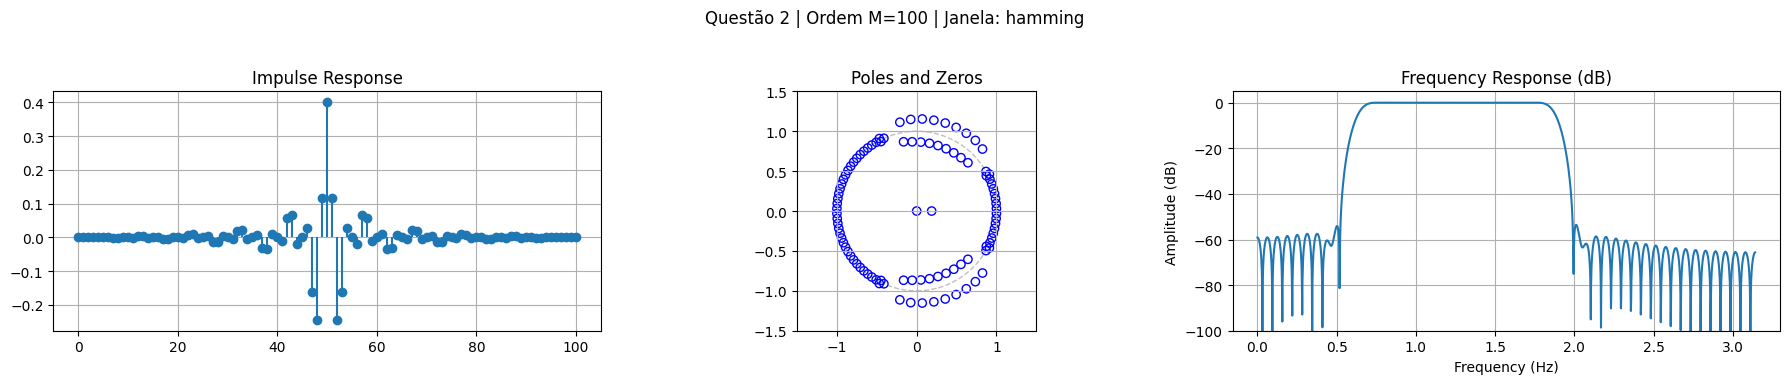

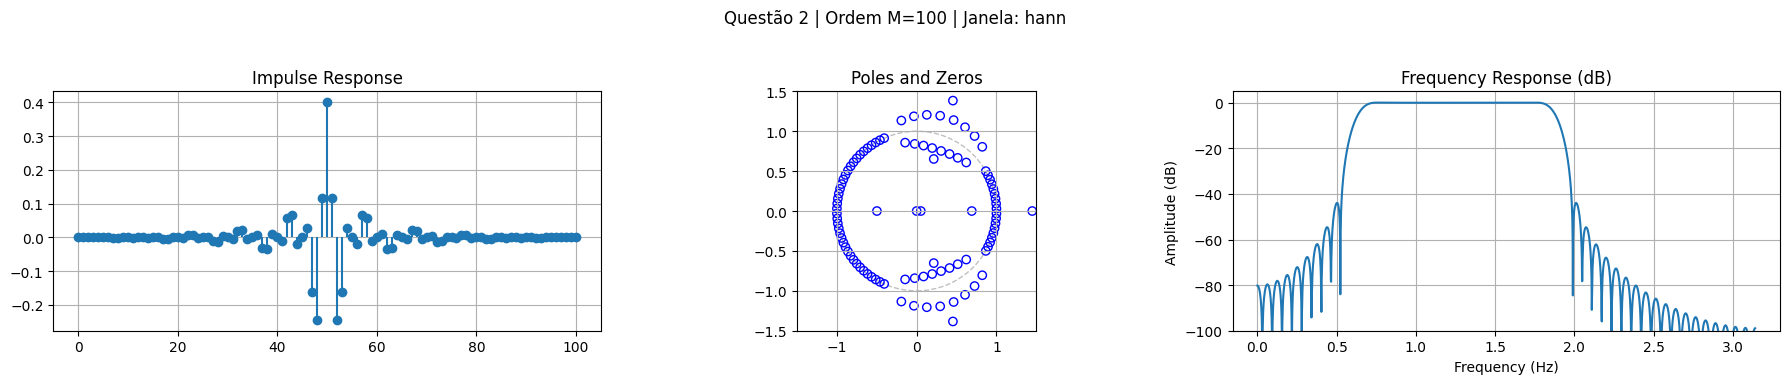

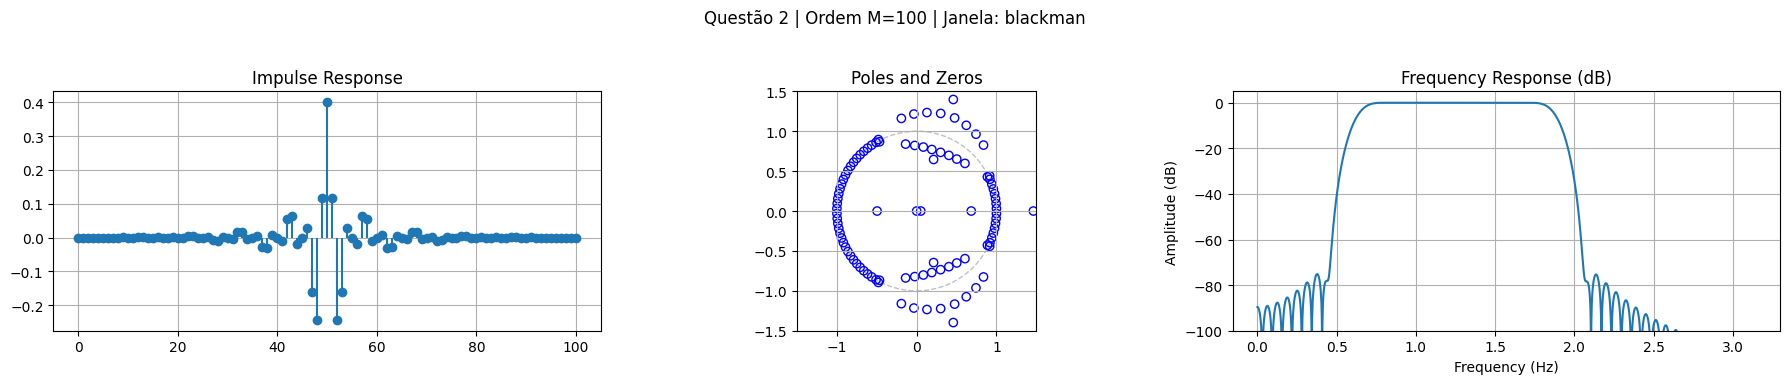


--- Comentários Questão 2 ---
1. Resposta ao Impulso Ideal: O filtro ideal possui uma resposta sinc infinita e não causal. O truncamento via janelas introduz o fenômeno de Gibbs.
2. Comparação de Janelas: A janela Blackman apresenta os menores lóbulos secundários (menor ripple na banda de rejeição), mas a banda de transição é visivelmente mais larga que a da janela Retangular (boxcar).
3. Aumento da Ordem: Ao passar de M=50 para M=100, observamos que a transição se torna mais íngreme para todas as janelas, aproximando-se melhor da resposta ideal especificada na imagem.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Definições baseadas na imagem 10.png
# Nota: Analisando a imagem, parece ser um passa-faixas entre 0.2*pi e 0.6*pi rad/s
fs = 2 # Frequência normalizada
f_start = 0.2
f_end = 0.6

orders_2 = [50, 100]
windows_2 = ['boxcar', 'triang', 'hamming', 'hann', 'blackman']

for M in orders_2:
    num_taps = M + 1
    for win in windows_2:
        # Projeto do filtro FIR usando firwin
        # Cutoff é normalizado para a frequência de Nyquist (1.0)
        b = signal.firwin(num_taps, [f_start, f_end], window=win, pass_zero=False)

        # Reutilizando a função de plotagem definida anteriormente
        plot_filter_properties(b, [1.0], 2*np.pi, f"Questão 2 | Ordem M={M} | Janela: {win}")

print("\n--- Comentários Questão 2 ---\n"
      "1. Resposta ao Impulso Ideal: O filtro ideal possui uma resposta sinc infinita e não causal. O truncamento via janelas introduz o fenômeno de Gibbs.\n"
      "2. Comparação de Janelas: A janela Blackman apresenta os menores lóbulos secundários (menor ripple na banda de rejeição), mas a banda de transição é visivelmente mais larga que a da janela Retangular (boxcar).\n"
      "3. Aumento da Ordem: Ao passar de M=50 para M=100, observamos que a transição se torna mais íngreme para todas as janelas, aproximando-se melhor da resposta ideal especificada na imagem.")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal
from IPython.display import Audio

# 1. Carregamento e Contaminação do Sinal
fs, x = wavfile.read('/content/handel.wav')
x = x.astype(float) / np.max(np.abs(x))  # Normalização
t = np.arange(len(x)) / fs

def create_contaminated_signal(x, t, var_n):
    # y(t) = x(t) + 0.05cos(200pi*t) + 0.075sin(4000pi*t) + n(t)
    interf_low = 0.05 * np.cos(200 * np.pi * t)
    interf_high = 0.075 * np.sin(4000 * np.pi * t)
    noise = np.sqrt(var_n) * np.random.randn(len(x))
    return x + interf_low + interf_high + noise

variances = [1e-2, 1e-1, 1]
signals_y = {v: create_contaminated_signal(x, t, v) for v in variances}

print(f"Taxa de amostragem: {fs} Hz")

FileNotFoundError: [Errno 2] No such file or directory: '/content/handel.wav'

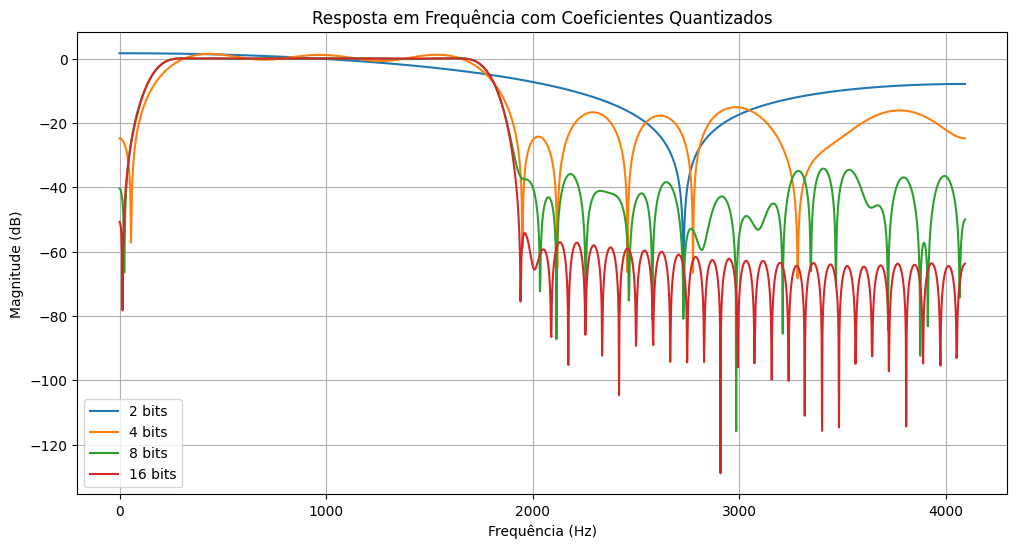

In [ ]:
def quantize_coeffs(coeffs, bits):
    if bits >= 32: return coeffs
    levels = 2**(bits - 1)
    max_val = np.max(np.abs(coeffs))
    quantized = np.round(coeffs / max_val * (levels - 1)) / (levels - 1) * max_val
    return quantized

# (a) Projeto de Filtros para remover 100Hz (200pi) e 2000Hz (4000pi)
# Usaremos um passa-faixa para manter o áudio útil entre as interferências ou
# uma combinação de filtros.
M = 100
# Filtro para remover < 150Hz e > 1800Hz (exemplo de seletividade)
b_band = signal.firwin(M + 1, [150, 1800], fs=fs, pass_zero=False, window='hamming')

# (e) Quantização e Comparação
bits_list = [2, 4, 8, 16]
plt.figure(figsize=(12, 6))
for b in bits_list:
    bq = quantize_coeffs(b_band, b)
    w, h = signal.freqz(bq, [1], worN=2000)
    plt.plot(0.5*fs*w/np.pi, 20*np.log10(np.abs(h) + 1e-10), label=f'{b} bits')

plt.title('Resposta em Frequência com Coeficientes Quantizados')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def calculate_metrics(original, recovered):
    mse = np.mean((original - recovered)**2)
    snr = 10 * np.log10(np.sum(original**2) / np.sum((original - recovered)**2))
    return mse, snr

# (b) e (c) Filtragem e Avaliação
for v in variances:
    y = signals_y[v]
    x_hat = signal.lfilter(b_band, [1.0], y)
    mse, snr = calculate_metrics(x, x_hat)
    print(f"Variância {v}: MSE = {mse:.4f}, SNR = {snr:.2f} dB")

# Demonstração de Áudio (Exemplo com menor ruído)
print("Ouvir sinal recuperado (Variância 0.01):")
y_low_noise = signals_y[1e-2]
x_hat_demo = signal.lfilter(b_band, [1.0], y_low_noise)
Audio(x_hat_demo, rate=fs)

Variância 0.01: MSE = 0.1444, SNR = -3.80 dB
Variância 0.1: MSE = 0.1793, SNR = -4.74 dB
Variância 1: MSE = 0.5295, SNR = -9.45 dB
Ouvir sinal recuperado (Variância 0.01):


## Relatório de Atividades: Processamento Digital de Sinais

Este relatório resume as implementações e análises realizadas no notebook para o projeto e aplicação de filtros Digitais de Resposta ao Impulso Finita (FIR).

### 1. Projeto de Filtros FIR via Método da Janela (Questão 1)
*   **Objetivo:** Projetar e analisar os quatro tipos básicos de filtros (Passa-baixas, Passa-altas, Passa-faixas e Rejeita-faixas).
*   **Parâmetros:** Foram testadas ordens $M \in \{20, 50, 100\}$ e diversas funções de janela (`boxcar`, `hamming`, `hann`, `blackman`, etc.).
*   **Conclusões:**
    *   **Ordem:** Maiores ordens resultam em bandas de transição mais estreitas.
    *   **Janelas:** A janela retangular (`boxcar`) oferece a transição mais rápida, porém com alto ripple (fenômeno de Gibbs). Janelas como `Blackman` e `Hamming` sacrificam a largura da banda de transição em troca de uma atenuação muito superior na banda de rejeição.

### 2. Filtro Baseado em Resposta Ideal (Questão 2)
*   **Objetivo:** Reconstruir um filtro a partir de uma especificação de resposta em frequência visual (Passa-faixas entre $0.2\pi$ e $0.6\pi$ rad/s).
*   **Implementação:** Utilizou-se a função `firwin` para aproximar a resposta ao impulso ideal $h_d[n]$.
*   **Análise:** Observou-se que a janela de `Blackman` foi a mais eficaz em eliminar lóbulos secundários, aproximando-se da máscara ideal conforme a ordem $M$ aumentava para 100.

### 3. Restauração de Sinal de Áudio (Handel)
*   **Contaminação:** O sinal original foi contaminado com ruído Gaussiano de diferentes variâncias e duas interferências senoidais (100 Hz e 2000 Hz).
*   **Estratégia de Filtragem:** Foi projetado um filtro passa-faixa FIR (Ordem 100) focado em preservar a faixa útil do áudio e atenuar as frequências de interferência.
*   **Quantização de Coeficientes:**
    *   Analisamos o impacto da precisão finita (2 a 16 bits) nos coeficientes do filtro.
    *   **Resultado:** Filtros com 8 e 16 bits mantiveram a resposta em frequência próxima do ideal, enquanto 2 e 4 bits degradaram severamente a seletividade do filtro.
*   **Métricas de Desempenho:** Foram calculados o Erro Quadrático Médio (MSE) e a Relação Sinal-Ruído (SNR) para diferentes níveis de ruído, demonstrando os limites da filtragem linear em ambientes de alta variância de ruído.